## Motifs and Discords

### set up and datasets

In [1]:
# ============================================================
# Cell 1 - Imports and global setup
# ============================================================

import sys
import subprocess
import importlib.util
import warnings

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Utility: install missing packages only if needed
# ------------------------------------------------------------
def ensure_package(package_name, import_name=None):
    """
    Install a package only if it is not already available.
    
    Parameters
    ----------
    package_name : str
        Name used by pip.
    import_name : str, optional
        Name used in the import statement. If None, package_name is used.
    """
    if import_name is None:
        import_name = package_name
    
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(f"Package already available: {package_name}")


# STUMPY is used to compute the Matrix Profile
ensure_package("stumpy")


# ------------------------------------------------------------
# Core libraries
# ------------------------------------------------------------
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import stumpy

from pathlib import Path
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


# ------------------------------------------------------------
# Global plotting settings
# ------------------------------------------------------------
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup completed successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"STUMPY version: {stumpy.__version__}")

Package already available: stumpy
Setup completed successfully.
NumPy version: 2.1.3
Pandas version: 2.3.2
STUMPY version: 1.14.1


In [5]:
# ============================================================
# Cell 2 - Load dataset for Matrix Profile motifs/discords
# ============================================================

from pathlib import Path
import pickle
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Candidate paths
# ------------------------------------------------------------
# The first path works if the notebook is run from the project root.
# The second path works if the notebook is inside a subfolder such as "notebooks/".
candidate_paths = [
    Path("dataset/CMI_timeseries_preprocessed_outputs.pkl"),
    Path("../dataset/CMI_timeseries_preprocessed_outputs.pkl")
]

DATA_PATH = None

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find CMI_timeseries_preprocessed_outputs.pkl.\n"
        "Checked paths:\n"
        + "\n".join(str(p) for p in candidate_paths)
    )

# ------------------------------------------------------------
# Load preprocessing output
# ------------------------------------------------------------
with open(DATA_PATH, "rb") as f:
    preprocessing_output = pickle.load(f)

print(f"Loaded file: {DATA_PATH}")
print(f"Loaded object type: {type(preprocessing_output)}")

print("\nAvailable keys:")
for key in preprocessing_output.keys():
    print(f"- {key}")

# ------------------------------------------------------------
# Select the correct dataset for motifs/discords
# ------------------------------------------------------------
CMI_timeseries_motif = preprocessing_output["CMI_timeseries_subject_scaled"]

signal_cols = preprocessing_output["signal_cols"]
id_col = preprocessing_output["id_col"]
target_col = preprocessing_output["target_col"]

print("\nSelected dataset: CMI_timeseries_subject_scaled")
print(f"Number of time-series windows: {len(CMI_timeseries_motif)}")
print(f"Signal columns: {signal_cols}")
print(f"ID column: {id_col}")
print(f"Target column: {target_col}")

# ------------------------------------------------------------
# Basic structure check
# ------------------------------------------------------------
first_ts = CMI_timeseries_motif[0]

print("\nFirst time-series window:")
print(f"Type: {type(first_ts)}")
print(f"Shape: {first_ts.shape}")
print(f"Columns: {first_ts.columns.tolist()}")

display(first_ts.head())

# ------------------------------------------------------------
# Metadata summary
# ------------------------------------------------------------
metadata_rows = []

for i, ts_df in enumerate(CMI_timeseries_motif):
    metadata_rows.append({
        "series_index": i,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0],
        "length": len(ts_df)
    })

motif_metadata_df = pd.DataFrame(metadata_rows)

print("\nMetadata summary:")
print(f"Number of windows: {len(motif_metadata_df)}")
print(f"Number of unique subjects: {motif_metadata_df['subject_id'].nunique()}")

print("\nTarget distribution at window level:")
display(motif_metadata_df["target"].value_counts().sort_index())

print("\nTime-series length distribution:")
display(motif_metadata_df["length"].describe())

display(motif_metadata_df.head())

Loaded file: ../dataset/CMI_timeseries_preprocessed_outputs.pkl
Loaded object type: <class 'dict'>

Available keys:
- CMI_timeseries_preprocessed
- CMI_timeseries_global_scaled
- CMI_timeseries_subject_scaled
- signal_cols
- id_col
- target_col
- target_df
- filtered_target_df
- non_wear_df
- hampel_summary_df

Selected dataset: CMI_timeseries_subject_scaled
Number of time-series windows: 4310
Signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
ID column: id
Target column: sii_binary

First time-series window:
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (200, 13)
Columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']


,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.577562,-0.341300,0.581710,-0.092658,0.596364,0.0,-0.134081,4023.000000,4.0,4.0,253.0,2265,0
1,0.132110,0.583135,-0.149255,0.069412,-0.110976,0.0,-0.144415,4023.000000,4.0,4.0,253.0,2265,0
2,0.258922,-0.716983,-0.281656,0.896904,-0.272399,0.0,-0.301142,4023.000000,4.0,4.0,253.0,2265,0
3,-0.128558,-1.123760,0.370799,0.380506,0.411645,0.0,-0.363996,4022.616699,4.0,4.0,253.0,2265,0
4,-0.038265,-0.846818,0.582961,0.228149,0.579831,0.0,-0.325248,4020.583252,4.0,4.0,253.0,2265,0



Metadata summary:
Number of windows: 4310
Number of unique subjects: 375

Target distribution at window level:


target
0    2888
1    1422
Name: count, dtype: int64


Time-series length distribution:


count    4310.0
mean      200.0
std         0.0
min       200.0
25%       200.0
50%       200.0
75%       200.0
max       200.0
Name: length, dtype: float64

,series_index,subject_id,target,length
0,0,2265,0,200
1,1,3042,1,200
2,2,1647,1,200
3,3,736,0,200
4,4,1044,0,200


Selected signal for all motif/discord analyses: enmo

Number of candidate windows with target=0: 2888

Selected time-series window:
Series index: 0
Subject ID: 2265
Target: 0
Signal: enmo
Length: 200
Minimum value: -0.7621
Maximum value: 7.5838
Mean value: 0.0000
Standard deviation: 1.0000


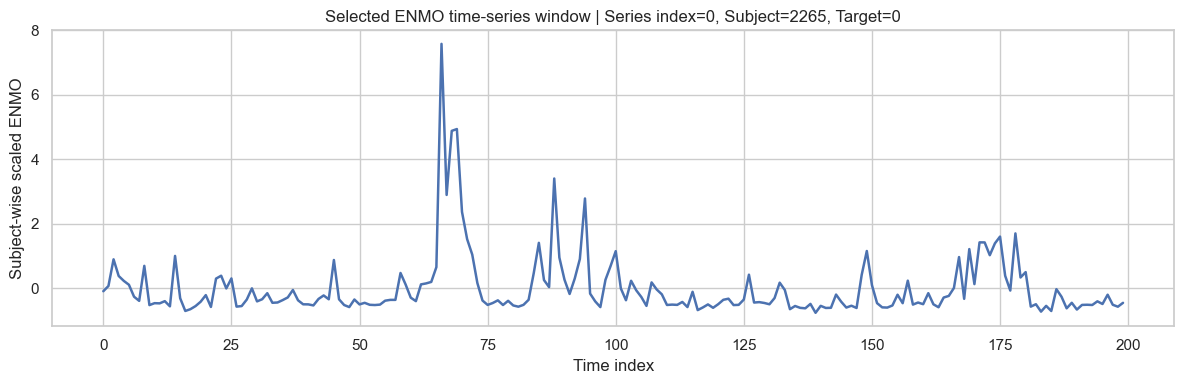

In [7]:
# ============================================================
# Cell 3 - Select ENMO as the only signal for Matrix Profile
# ============================================================

# ------------------------------------------------------------
# Fix the signal to analyse
# ------------------------------------------------------------
signal_to_analyze = "enmo"

if signal_to_analyze not in signal_cols:
    raise ValueError(
        f"Signal '{signal_to_analyze}' not found in signal_cols.\n"
        f"Available signals are: {signal_cols}"
    )

print(f"Selected signal for all motif/discord analyses: {signal_to_analyze}")

# ------------------------------------------------------------
# Choose one target class and one time-series window
# ------------------------------------------------------------
# We start from class 0 as an example.
# Later, we can repeat the same analysis for class 1 or for sampled windows.
TARGET_TO_ANALYZE = 0

candidate_windows = motif_metadata_df[
    motif_metadata_df["target"] == TARGET_TO_ANALYZE
].copy()

print(f"\nNumber of candidate windows with target={TARGET_TO_ANALYZE}: {len(candidate_windows)}")

# ------------------------------------------------------------
# Select the first valid window for ENMO
# ------------------------------------------------------------
selected_series_index = None

for idx in candidate_windows["series_index"]:
    ts_candidate = CMI_timeseries_motif[idx]
    x_candidate = ts_candidate[signal_to_analyze].to_numpy(dtype=float)

    if np.all(np.isfinite(x_candidate)):
        selected_series_index = idx
        break

if selected_series_index is None:
    raise ValueError(
        f"No valid time-series window found for target={TARGET_TO_ANALYZE} "
        f"and signal={signal_to_analyze}."
    )

# ------------------------------------------------------------
# Extract selected ENMO time series
# ------------------------------------------------------------
ts_selected = CMI_timeseries_motif[selected_series_index].copy()
x = ts_selected[signal_to_analyze].to_numpy(dtype=float)

selected_subject_id = ts_selected[id_col].iloc[0]
selected_target = ts_selected[target_col].iloc[0]

print("\nSelected time-series window:")
print(f"Series index: {selected_series_index}")
print(f"Subject ID: {selected_subject_id}")
print(f"Target: {selected_target}")
print(f"Signal: {signal_to_analyze}")
print(f"Length: {len(x)}")
print(f"Minimum value: {np.min(x):.4f}")
print(f"Maximum value: {np.max(x):.4f}")
print(f"Mean value: {np.mean(x):.4f}")
print(f"Standard deviation: {np.std(x):.4f}")

# ------------------------------------------------------------
# Plot selected ENMO signal
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(x, linewidth=1.8)
plt.title(
    f"Selected ENMO time-series window | "
    f"Series index={selected_series_index}, Subject={selected_subject_id}, "
    f"Target={selected_target}"
)
plt.xlabel("Time index")
plt.ylabel("Subject-wise scaled ENMO")
plt.grid(True)
plt.tight_layout()
plt.show()

Matrix Profile subsequence setting
Time-series length: 200
Subsequence length m: 20
Number of candidate subsequences: 181
Subsequence length as percentage of full window: 10.0%


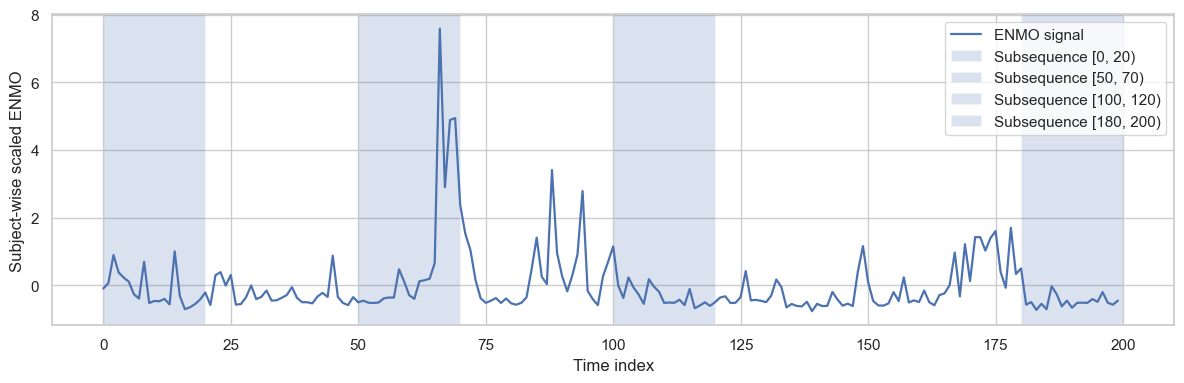

In [9]:
# ============================================================
# Cell 4 - Set subsequence length for Matrix Profile
# ============================================================

# ------------------------------------------------------------
# Matrix Profile subsequence length
# ------------------------------------------------------------
m = 20

if m <= 2:
    raise ValueError("m must be larger than 2.")

if m >= len(x):
    raise ValueError(
        f"m must be smaller than the length of the time series. "
        f"Received m={m}, len(x)={len(x)}."
    )

n_subsequences = len(x) - m + 1

print("Matrix Profile subsequence setting")
print(f"Time-series length: {len(x)}")
print(f"Subsequence length m: {m}")
print(f"Number of candidate subsequences: {n_subsequences}")
print(f"Subsequence length as percentage of full window: {100 * m / len(x):.1f}%")

# ------------------------------------------------------------
# Plot selected ENMO signal and show some example subsequences
# ------------------------------------------------------------
example_starts = [
    0,
    len(x) // 4,
    len(x) // 2,
    len(x) - m
]

plt.figure(figsize=(12, 4))
plt.plot(x, linewidth=1.6, label="ENMO signal")

for start in example_starts:
    end = start + m
    plt.axvspan(start, end, alpha=0.20, label=f"Subsequence [{start}, {end})")


plt.xlabel("Time index")
plt.ylabel("Subject-wise scaled ENMO")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Matrix Profile computed successfully.
Matrix Profile shape: (181, 4)
Number of Matrix Profile values: 181

Global motif pair:
Motif subsequence start index: 26
Nearest-neighbour subsequence start index: 47
Matrix Profile distance: 2.2031

Global discord:
Discord subsequence start index: 12
Matrix Profile distance: 4.2754


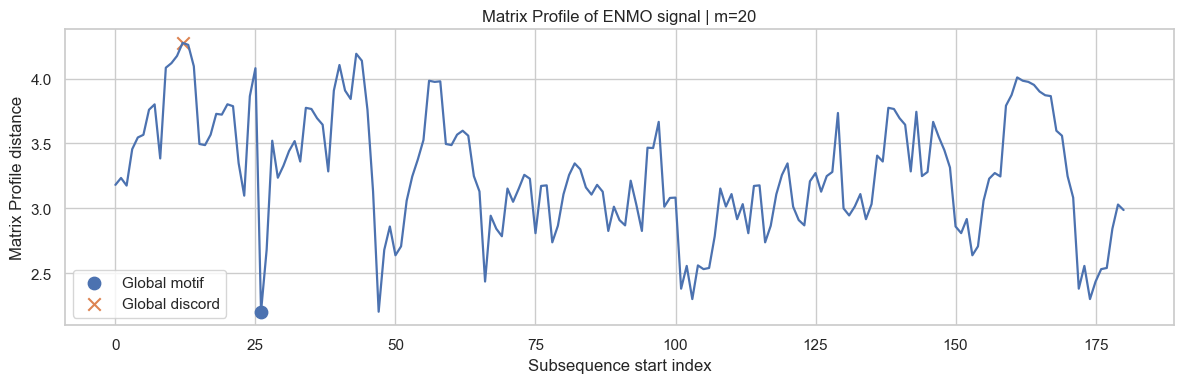

In [10]:
# ============================================================
# Cell 5 - Compute Matrix Profile for the selected ENMO series
# ============================================================

# ------------------------------------------------------------
# Compute Matrix Profile
# ------------------------------------------------------------
mp = stumpy.stump(x, m=m)

# STUMPY output columns:
# column 0 = Matrix Profile values
# column 1 = Matrix Profile indices, i.e. nearest-neighbour index
mp_values = mp[:, 0].astype(float)
mp_indices = mp[:, 1].astype(int)

print("Matrix Profile computed successfully.")
print(f"Matrix Profile shape: {mp.shape}")
print(f"Number of Matrix Profile values: {len(mp_values)}")

# ------------------------------------------------------------
# Identify the global motif pair
# ------------------------------------------------------------
motif_start = int(np.argmin(mp_values))
motif_nn = int(mp_indices[motif_start])
motif_distance = float(mp_values[motif_start])

print("\nGlobal motif pair:")
print(f"Motif subsequence start index: {motif_start}")
print(f"Nearest-neighbour subsequence start index: {motif_nn}")
print(f"Matrix Profile distance: {motif_distance:.4f}")

# ------------------------------------------------------------
# Identify the global discord
# ------------------------------------------------------------
discord_start = int(np.argmax(mp_values))
discord_distance = float(mp_values[discord_start])

print("\nGlobal discord:")
print(f"Discord subsequence start index: {discord_start}")
print(f"Matrix Profile distance: {discord_distance:.4f}")

# ------------------------------------------------------------
# Plot Matrix Profile
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(mp_values, linewidth=1.6)
plt.scatter(motif_start, motif_distance, s=80, marker="o", label="Global motif")
plt.scatter(discord_start, discord_distance, s=80, marker="x", label="Global discord")

plt.title(f"Matrix Profile of ENMO signal | m={m}")
plt.xlabel("Subsequence start index")
plt.ylabel("Matrix Profile distance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Global motif pair
- Motif start index: 26
- Motif nearest-neighbour start index: 47
- Motif distance: 2.2031

Global discord
- Discord start index: 12
- Discord distance: 4.2754


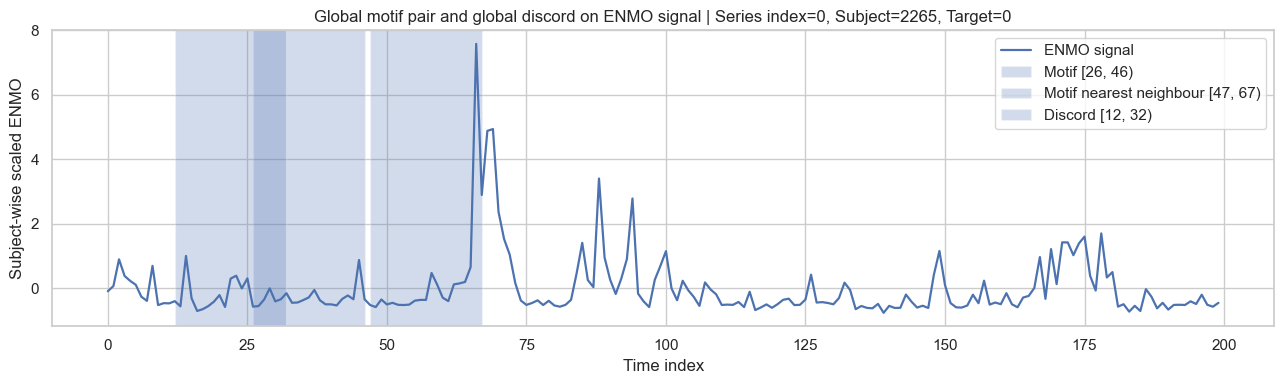

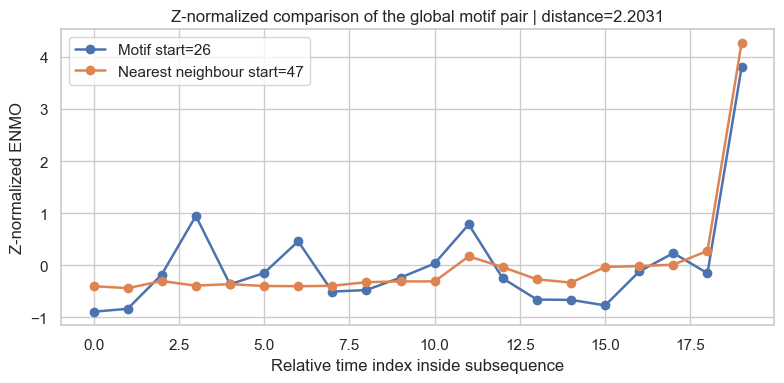

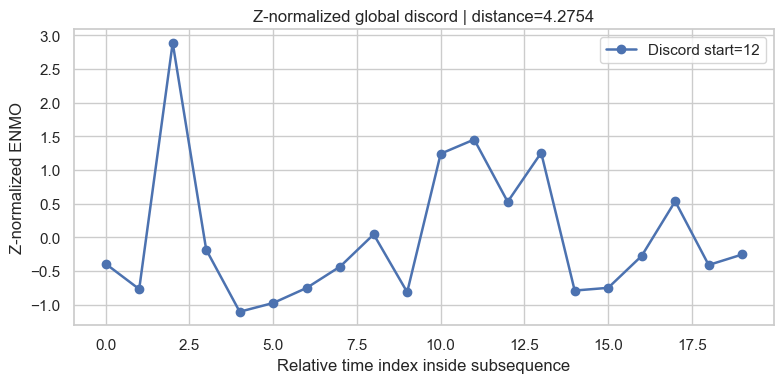

In [11]:
# ============================================================
# Cell 6 - Visualize global motif pair and global discord
# ============================================================

# ------------------------------------------------------------
# Extract subsequences
# ------------------------------------------------------------
motif_subseq = x[motif_start:motif_start + m]
motif_nn_subseq = x[motif_nn:motif_nn + m]
discord_subseq = x[discord_start:discord_start + m]

# ------------------------------------------------------------
# Utility: z-normalization for shape comparison
# ------------------------------------------------------------
def z_normalize_subsequence(subseq):
    """
    Z-normalize a subsequence to compare its shape independently
    of absolute level and amplitude.
    """
    subseq = np.asarray(subseq, dtype=float)
    std = np.std(subseq)

    if std == 0:
        return subseq - np.mean(subseq)

    return (subseq - np.mean(subseq)) / std


motif_subseq_z = z_normalize_subsequence(motif_subseq)
motif_nn_subseq_z = z_normalize_subsequence(motif_nn_subseq)
discord_subseq_z = z_normalize_subsequence(discord_subseq)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------
print("Global motif pair")
print(f"- Motif start index: {motif_start}")
print(f"- Motif nearest-neighbour start index: {motif_nn}")
print(f"- Motif distance: {motif_distance:.4f}")

print("\nGlobal discord")
print(f"- Discord start index: {discord_start}")
print(f"- Discord distance: {discord_distance:.4f}")

# ------------------------------------------------------------
# Plot 1: original series with highlighted motif and discord regions
# ------------------------------------------------------------
plt.figure(figsize=(13, 4))

plt.plot(x, linewidth=1.6, label="ENMO signal")

plt.axvspan(
    motif_start,
    motif_start + m,
    alpha=0.25,
    label=f"Motif [{motif_start}, {motif_start + m})"
)

plt.axvspan(
    motif_nn,
    motif_nn + m,
    alpha=0.25,
    label=f"Motif nearest neighbour [{motif_nn}, {motif_nn + m})"
)

plt.axvspan(
    discord_start,
    discord_start + m,
    alpha=0.25,
    label=f"Discord [{discord_start}, {discord_start + m})"
)

plt.title(
    f"Global motif pair and global discord on ENMO signal | "
    f"Series index={selected_series_index}, Subject={selected_subject_id}, Target={selected_target}"
)
plt.xlabel("Time index")
plt.ylabel("Subject-wise scaled ENMO")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: z-normalized motif pair comparison
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))

plt.plot(motif_subseq_z, marker="o", linewidth=1.8, label=f"Motif start={motif_start}")
plt.plot(motif_nn_subseq_z, marker="o", linewidth=1.8, label=f"Nearest neighbour start={motif_nn}")

plt.title(f"Z-normalized comparison of the global motif pair | distance={motif_distance:.4f}")
plt.xlabel("Relative time index inside subsequence")
plt.ylabel("Z-normalized ENMO")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 3: z-normalized discord shape
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))

plt.plot(discord_subseq_z, marker="o", linewidth=1.8, label=f"Discord start={discord_start}")

plt.title(f"Z-normalized global discord | distance={discord_distance:.4f}")
plt.xlabel("Relative time index inside subsequence")
plt.ylabel("Z-normalized ENMO")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Cell 7 - Define reusable motif/discord extraction function
# ============================================================

def extract_global_motif_discord_features(
    ts_df,
    series_index,
    signal_col="enmo",
    m=20,
    id_col=id_col,
    target_col=target_col
):
    """
    Extract global motif and global discord features from one ENMO time-series window.

    This function allows motif and discord regions to overlap.
    No exclusion zone is applied.

    Parameters
    ----------
    ts_df : pd.DataFrame
        One time-series window.
    series_index : int
        Index of the time-series window in the full list.
    signal_col : str
        Signal column to analyse. Here we use ENMO.
    m : int
        Subsequence length for Matrix Profile.
    id_col : str
        Subject identifier column.
    target_col : str
        Target column.

    Returns
    -------
    dict
        Dictionary containing metadata and Matrix Profile motif/discord features.
    """

    # --------------------------------------------------------
    # Extract signal
    # --------------------------------------------------------
    x_local = ts_df[signal_col].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Basic validity checks
    # --------------------------------------------------------
    if len(x_local) <= m:
        return {
            "series_index": series_index,
            "subject_id": ts_df[id_col].iloc[0],
            "target": ts_df[target_col].iloc[0],
            "valid": False,
            "error": "Time series shorter than or equal to m"
        }

    if not np.all(np.isfinite(x_local)):
        return {
            "series_index": series_index,
            "subject_id": ts_df[id_col].iloc[0],
            "target": ts_df[target_col].iloc[0],
            "valid": False,
            "error": "Non-finite values in signal"
        }

    # --------------------------------------------------------
    # Compute Matrix Profile
    # --------------------------------------------------------
    mp_local = stumpy.stump(x_local, m=m)

    mp_values_local = mp_local[:, 0].astype(float)
    mp_indices_local = mp_local[:, 1].astype(int)

    # --------------------------------------------------------
    # Global motif pair
    # --------------------------------------------------------
    motif_start_local = int(np.argmin(mp_values_local))
    motif_nn_local = int(mp_indices_local[motif_start_local])
    motif_distance_local = float(mp_values_local[motif_start_local])

    # --------------------------------------------------------
    # Global discord
    # --------------------------------------------------------
    discord_start_local = int(np.argmax(mp_values_local))
    discord_distance_local = float(mp_values_local[discord_start_local])

    # --------------------------------------------------------
    # Extract subsequences
    # --------------------------------------------------------
    motif_subseq_local = x_local[motif_start_local:motif_start_local + m]
    motif_nn_subseq_local = x_local[motif_nn_local:motif_nn_local + m]
    discord_subseq_local = x_local[discord_start_local:discord_start_local + m]

    # --------------------------------------------------------
    # Return compact feature dictionary
    # --------------------------------------------------------
    return {
        "series_index": series_index,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0],
        "valid": True,
        "error": None,

        "length": len(x_local),
        "m": m,

        "motif_start": motif_start_local,
        "motif_nn_start": motif_nn_local,
        "motif_distance": motif_distance_local,

        "discord_start": discord_start_local,
        "discord_distance": discord_distance_local,

        "mp_mean": float(np.mean(mp_values_local)),
        "mp_std": float(np.std(mp_values_local)),
        "mp_min": float(np.min(mp_values_local)),
        "mp_max": float(np.max(mp_values_local)),

        "motif_mean": float(np.mean(motif_subseq_local)),
        "motif_std": float(np.std(motif_subseq_local)),
        "motif_min": float(np.min(motif_subseq_local)),
        "motif_max": float(np.max(motif_subseq_local)),
        "motif_range": float(np.max(motif_subseq_local) - np.min(motif_subseq_local)),

        "motif_nn_mean": float(np.mean(motif_nn_subseq_local)),
        "motif_nn_std": float(np.std(motif_nn_subseq_local)),
        "motif_nn_min": float(np.min(motif_nn_subseq_local)),
        "motif_nn_max": float(np.max(motif_nn_subseq_local)),
        "motif_nn_range": float(np.max(motif_nn_subseq_local) - np.min(motif_nn_subseq_local)),

        "discord_mean": float(np.mean(discord_subseq_local)),
        "discord_std": float(np.std(discord_subseq_local)),
        "discord_min": float(np.min(discord_subseq_local)),
        "discord_max": float(np.max(discord_subseq_local)),
        "discord_range": float(np.max(discord_subseq_local) - np.min(discord_subseq_local)),
    }


# ------------------------------------------------------------
# Test the function on the selected example window
# ------------------------------------------------------------
example_features = extract_global_motif_discord_features(
    ts_df=ts_selected,
    series_index=selected_series_index,
    signal_col=signal_to_analyze,
    m=m
)

example_features_df = pd.DataFrame([example_features])

print("Feature extraction test on the selected ENMO window:")
display(example_features_df.T)

Feature extraction test on the selected ENMO window:


,0
series_index,0
subject_id,2265
target,0
valid,True
error,None
length,200
m,20
motif_start,26
motif_nn_start,47
motif_distance,2.203068


## Extraction on all enmo windows

In [14]:
# ============================================================
# Cell 8 - Apply motif/discord extraction to all ENMO windows
# ============================================================

from tqdm.auto import tqdm
import time

# ------------------------------------------------------------
# Apply the extraction function to all time-series windows
# ------------------------------------------------------------
start_time = time.time()

all_features = []

for series_index, ts_df in tqdm(
    enumerate(CMI_timeseries_motif),
    total=len(CMI_timeseries_motif),
    desc="Extracting motifs and discords"
):
    features = extract_global_motif_discord_features(
        ts_df=ts_df,
        series_index=series_index,
        signal_col=signal_to_analyze,
        m=m,
        id_col=id_col,
        target_col=target_col
    )
    
    all_features.append(features)

elapsed_time = time.time() - start_time

# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------
motif_discord_features_df = pd.DataFrame(all_features)

print("Motif/discord feature extraction completed.")
print(f"Elapsed time: {elapsed_time:.2f} seconds")
print(f"Number of processed windows: {len(motif_discord_features_df)}")

# ------------------------------------------------------------
# Validity check
# ------------------------------------------------------------
print("\nValidity summary:")
display(motif_discord_features_df["valid"].value_counts(dropna=False))

if "error" in motif_discord_features_df.columns:
    print("\nError summary:")
    display(motif_discord_features_df["error"].value_counts(dropna=False))

# ------------------------------------------------------------
# Keep only valid extractions
# ------------------------------------------------------------
motif_discord_valid_df = motif_discord_features_df[
    motif_discord_features_df["valid"] == True
].copy()

print("\nValid feature dataframe:")
print(f"Shape: {motif_discord_valid_df.shape}")

display(motif_discord_valid_df.head())

Extracting motifs and discords:   0%|          | 0/4310 [00:00<?, ?it/s]

Motif/discord feature extraction completed.
Elapsed time: 20.28 seconds
Number of processed windows: 4310

Validity summary:


valid
True    4310
Name: count, dtype: int64


Error summary:


error
None    4310
Name: count, dtype: int64


Valid feature dataframe:
Shape: (4310, 31)


,series_index,subject_id,target,valid,error,length,m,motif_start,motif_nn_start,motif_distance,...,motif_nn_mean,motif_nn_std,motif_nn_min,motif_nn_max,motif_nn_range,discord_mean,discord_std,discord_min,discord_max,discord_range
0,0,2265,0,True,None,200,20,26,47,2.203068,...,0.177096,1.735941,-0.584321,7.583810,8.168131,-0.231463,0.427804,-0.704988,1.003225,1.708213
1,1,3042,1,True,None,200,20,51,99,1.832842,...,0.203062,1.717813,-0.630383,7.412018,8.042401,-0.600106,0.177488,-0.879333,-0.188089,0.691244
2,2,1647,1,True,None,200,20,24,111,2.572615,...,0.775456,1.501598,-0.623874,4.552778,5.176652,0.291976,0.732682,-0.649792,1.962203,2.611995
3,3,736,0,True,None,200,20,137,153,2.204756,...,-0.116424,0.557455,-0.795957,1.420253,2.216210,-0.734355,0.115381,-0.836991,-0.368652,0.468340
4,4,1044,0,True,None,200,20,42,61,1.532264,...,0.765144,1.839545,-0.800589,5.304306,6.104895,-0.786943,0.065027,-0.866281,-0.561136,0.305145


In [15]:
# ============================================================
# Cell 9 - Clean feature dataframe and compare by target class
# ============================================================

# ------------------------------------------------------------
# Clean valid dataframe
# ------------------------------------------------------------
motif_discord_valid_df = motif_discord_valid_df.drop(columns=["error"], errors="ignore").copy()

# Ensure target is integer
motif_discord_valid_df["target"] = motif_discord_valid_df["target"].astype(int)

print("Cleaned motif/discord feature dataframe:")
print(f"Shape: {motif_discord_valid_df.shape}")

print("\nTarget distribution:")
display(motif_discord_valid_df["target"].value_counts().sort_index())

# ------------------------------------------------------------
# Main features to compare
# ------------------------------------------------------------
main_feature_cols = [
    "motif_distance",
    "discord_distance",
    "mp_mean",
    "mp_std",
    "motif_start",
    "motif_nn_start",
    "discord_start",
    "motif_range",
    "discord_range",
    "motif_std",
    "discord_std"
]

# Keep only available columns
main_feature_cols = [
    col for col in main_feature_cols
    if col in motif_discord_valid_df.columns
]

# ------------------------------------------------------------
# Descriptive statistics by target
# ------------------------------------------------------------
summary_by_target = (
    motif_discord_valid_df
    .groupby("target")[main_feature_cols]
    .agg(["mean", "std", "median", "min", "max"])
)

print("\nDescriptive statistics of motif/discord features by target:")
display(summary_by_target)

# ------------------------------------------------------------
# Compact table: means and medians by target
# ------------------------------------------------------------
compact_summary = (
    motif_discord_valid_df
    .groupby("target")[main_feature_cols]
    .agg(["mean", "median"])
)

print("\nCompact summary: mean and median by target:")
display(compact_summary)

Cleaned motif/discord feature dataframe:
Shape: (4310, 30)

Target distribution:


target
0    2888
1    1422
Name: count, dtype: int64


Descriptive statistics of motif/discord features by target:


motif_distance                                    discord_distance  \
                 mean       std    median  min       max             mean   
target                                                                      
0            1.982190  0.480770  2.005894  0.0  3.421003         4.555666   
1            1.975345  0.503492  2.000592  0.0  3.322797         4.557294   

                                                ... motif_std            \
             std    median       min       max  ...      mean       std   
target                                          ...                       
0       0.181632  4.555941  3.790128  5.373856  ...  0.801004  0.509574   
1       0.185968  4.561638  3.802612  5.142414  ...  0.835581  0.494186   

                                discord_std                                    \
          median  min       max        mean       std    median           min   
target                                                                          
0       0.689339  0.0  2.905384    0.432688  0.339406  0.338758  7.992358e-07   
1       0.743709  0.0  2.979421    0.460509  0.346534  0.372745  0.000000e+00   

                  
             max  
target            
0       2.188877  
1       2.197721  

[2 rows x 55 columns]


Compact summary: mean and median by target:


motif_distance           discord_distance             mp_mean  \
                 mean    median             mean    median      mean   
target                                                                 
0            1.982190  2.005894         4.555666  4.555941  3.343143   
1            1.975345  2.000592         4.557294  4.561638  3.360351   

                    mp_std           motif_start         ... discord_start  \
          median      mean    median        mean median  ...          mean   
target                                                   ...                 
0       3.355673  0.576498  0.562761   59.200831   53.0  ...     77.003463   
1       3.384871  0.576614  0.558715   58.633615   53.5  ...     80.973277   

              motif_range           discord_range           motif_std  \
       median        mean    median          mean    median      mean   
target                                                                  
0        71.0    3.159289  2.755633      1.566605  1.234609  0.801004   
1        78.0    3.321177  2.942697      1.649962  1.355265  0.835581   

                 discord_std            
          median        mean    median  
target                                  
0       0.689339    0.432688  0.338758  
1       0.743709    0.460509  0.372745  

[2 rows x 22 columns]

Target-wise comparison of motif/discord features:


,feature,mean_target_0,mean_target_1,median_target_0,median_target_1,mean_difference_1_minus_0,median_difference_1_minus_0,cohen_d_1_vs_0,rank_biserial,mannwhitney_pvalue,ks_pvalue,abs_cohen_d
7,discord_std,0.432688,0.460509,0.338758,0.372745,0.027820,0.033988,0.081399,-0.055445,0.003036,0.006089,0.081399
4,motif_range,3.159289,3.321177,2.755633,2.942697,0.161888,0.187064,0.080446,-0.058920,0.001634,0.000190,0.080446
9,discord_start,77.003463,80.973277,71.000000,78.000000,3.969814,7.000000,0.070836,-0.044849,0.016503,0.010208,0.070836
6,motif_std,0.801004,0.835581,0.689339,0.743709,0.034577,0.054370,0.068531,-0.053121,0.004515,0.001317,0.068531
5,discord_range,1.566605,1.649962,1.234609,1.355265,0.083357,0.120657,0.067687,-0.051103,0.006297,0.014722,0.067687
2,mp_mean,3.343143,3.360351,3.355673,3.384871,0.017208,0.029198,0.064668,-0.051187,0.006212,0.001089,0.064668
8,motif_start,59.200831,58.633615,53.000000,53.500000,-0.567216,0.500000,-0.014604,0.008427,0.652363,0.536336,0.014604
0,motif_distance,1.982190,1.975345,2.005894,2.000592,-0.006845,-0.005302,-0.014015,0.011745,0.530108,0.233638,0.014015
1,discord_distance,4.555666,4.557294,4.555941,4.561638,0.001628,0.005697,0.008890,-0.016318,0.383041,0.319311,0.008890
3,mp_std,0.576498,0.576614,0.562761,0.558715,0.000116,-0.004046,0.000849,0.013338,0.475846,0.165916,0.000849


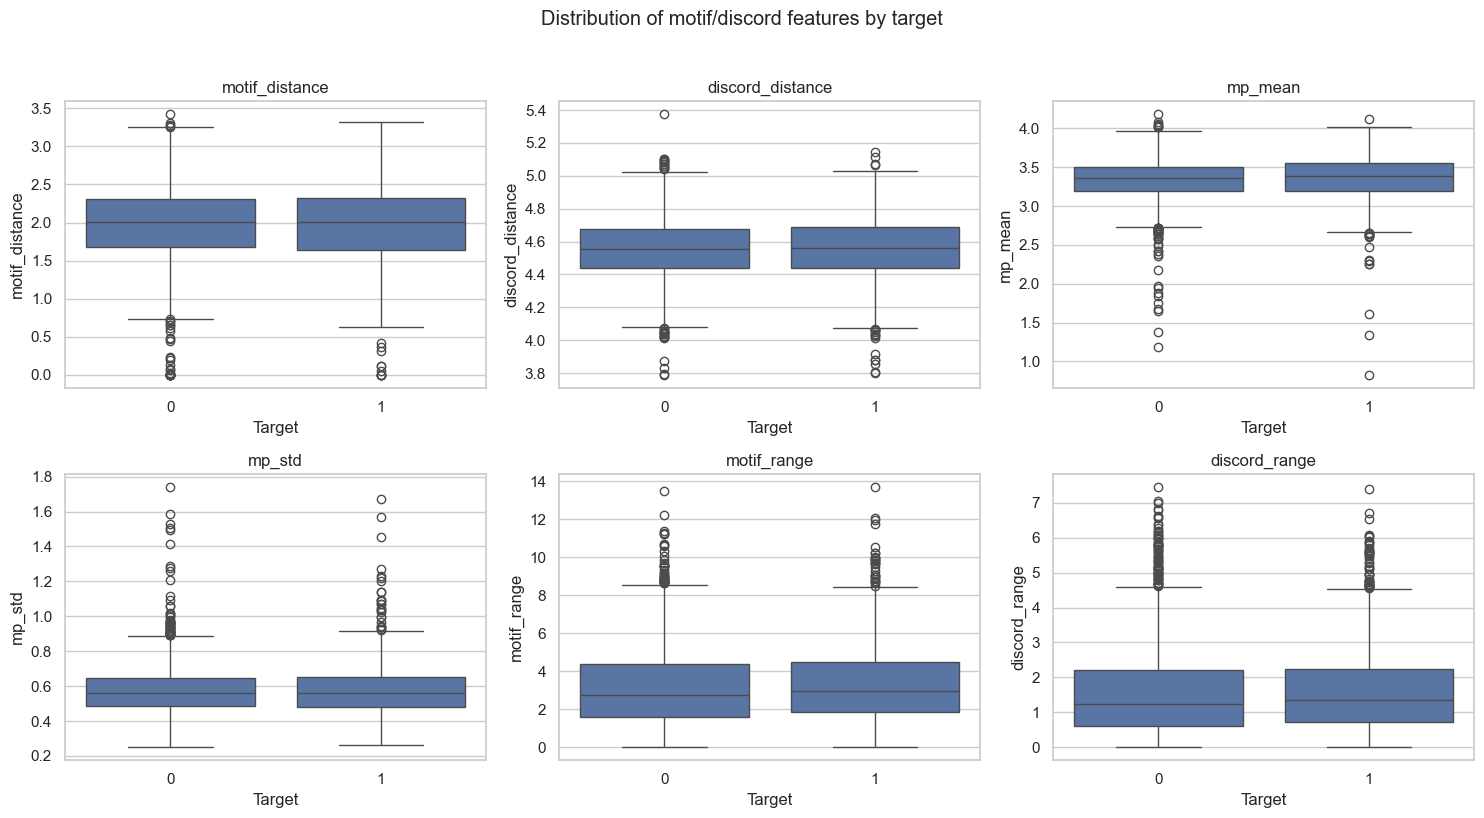

In [16]:
# ============================================================
# Cell 10 - Visual comparison and effect sizes by target
# ============================================================

from scipy.stats import mannwhitneyu, ks_2samp

features_to_compare = [
    "motif_distance",
    "discord_distance",
    "mp_mean",
    "mp_std",
    "motif_range",
    "discord_range",
    "motif_std",
    "discord_std",
    "motif_start",
    "discord_start"
]

features_to_compare = [
    col for col in features_to_compare
    if col in motif_discord_valid_df.columns
]

def cohen_d(x0, x1):
    x0 = np.asarray(x0, dtype=float)
    x1 = np.asarray(x1, dtype=float)

    n0 = len(x0)
    n1 = len(x1)

    s0 = np.var(x0, ddof=1)
    s1 = np.var(x1, ddof=1)

    pooled_std = np.sqrt(((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2))

    if pooled_std == 0:
        return np.nan

    return (np.mean(x1) - np.mean(x0)) / pooled_std


def rank_biserial_from_u(u_stat, n0, n1):
    return (2 * u_stat / (n0 * n1)) - 1


comparison_rows = []

for feature in features_to_compare:
    x0 = motif_discord_valid_df.loc[
        motif_discord_valid_df["target"] == 0, feature
    ].dropna()

    x1 = motif_discord_valid_df.loc[
        motif_discord_valid_df["target"] == 1, feature
    ].dropna()

    mw = mannwhitneyu(x0, x1, alternative="two-sided")
    ks = ks_2samp(x0, x1)

    comparison_rows.append({
        "feature": feature,

        "mean_target_0": np.mean(x0),
        "mean_target_1": np.mean(x1),
        "median_target_0": np.median(x0),
        "median_target_1": np.median(x1),

        "mean_difference_1_minus_0": np.mean(x1) - np.mean(x0),
        "median_difference_1_minus_0": np.median(x1) - np.median(x0),

        "cohen_d_1_vs_0": cohen_d(x0, x1),
        "rank_biserial": rank_biserial_from_u(mw.statistic, len(x0), len(x1)),

        "mannwhitney_pvalue": mw.pvalue,
        "ks_pvalue": ks.pvalue
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df["abs_cohen_d"] = comparison_df["cohen_d_1_vs_0"].abs()
comparison_df = comparison_df.sort_values("abs_cohen_d", ascending=False)

print("Target-wise comparison of motif/discord features:")
display(comparison_df)

plot_features = [
    "motif_distance",
    "discord_distance",
    "mp_mean",
    "mp_std",
    "motif_range",
    "discord_range"
]

plot_features = [
    col for col in plot_features
    if col in motif_discord_valid_df.columns
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feature in zip(axes, plot_features):
    sns.boxplot(
        data=motif_discord_valid_df,
        x="target",
        y=feature,
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("Target")
    ax.set_ylabel(feature)

for ax in axes[len(plot_features):]:
    ax.axis("off")

plt.suptitle("Distribution of motif/discord features by target", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Cell 11 - Subject-level aggregation of motif/discord features
# ============================================================

# ------------------------------------------------------------
# Check whether each subject has a unique target
# ------------------------------------------------------------
target_consistency = (
    motif_discord_valid_df
    .groupby("subject_id")["target"]
    .nunique()
)

print("Target consistency across subjects:")
display(target_consistency.value_counts().sort_index())

if (target_consistency > 1).any():
    print("WARNING: Some subjects have more than one target value.")
    inconsistent_subjects = target_consistency[target_consistency > 1].index.tolist()
    print(f"Number of inconsistent subjects: {len(inconsistent_subjects)}")
else:
    print("Each subject has a unique target value.")

# ------------------------------------------------------------
# Features to aggregate at subject level
# ------------------------------------------------------------
subject_feature_cols = [
    "motif_distance",
    "discord_distance",
    "mp_mean",
    "mp_std",
    "mp_min",
    "mp_max",
    "motif_start",
    "motif_nn_start",
    "discord_start",
    "motif_mean",
    "motif_std",
    "motif_min",
    "motif_max",
    "motif_range",
    "motif_nn_mean",
    "motif_nn_std",
    "motif_nn_min",
    "motif_nn_max",
    "motif_nn_range",
    "discord_mean",
    "discord_std",
    "discord_min",
    "discord_max",
    "discord_range"
]

subject_feature_cols = [
    col for col in subject_feature_cols
    if col in motif_discord_valid_df.columns
]

# ------------------------------------------------------------
# Aggregate features per subject
# ------------------------------------------------------------
aggregation_dict = {
    "target": lambda x: x.mode().iloc[0],
    "series_index": "count"
}

for col in subject_feature_cols:
    aggregation_dict[col] = "mean"

subject_motif_discord_df = (
    motif_discord_valid_df
    .groupby("subject_id")
    .agg(aggregation_dict)
    .reset_index()
    .rename(columns={"series_index": "n_windows"})
)

subject_motif_discord_df["target"] = subject_motif_discord_df["target"].astype(int)

print("\nSubject-level motif/discord dataframe:")
print(f"Shape: {subject_motif_discord_df.shape}")

print("\nTarget distribution at subject level:")
display(subject_motif_discord_df["target"].value_counts().sort_index())

print("\nNumber of windows per subject:")
display(subject_motif_discord_df["n_windows"].describe())

display(subject_motif_discord_df.head())

# ------------------------------------------------------------
# Subject-level descriptive statistics by target
# ------------------------------------------------------------
subject_summary_by_target = (
    subject_motif_discord_df
    .groupby("target")[subject_feature_cols]
    .agg(["mean", "std", "median", "min", "max"])
)

print("\nSubject-level descriptive statistics by target:")
display(subject_summary_by_target)

Target consistency across subjects:


target
1    375
Name: count, dtype: int64

Each subject has a unique target value.

Subject-level motif/discord dataframe:
Shape: (375, 27)

Target distribution at subject level:


target
0    236
1    139
Name: count, dtype: int64


Number of windows per subject:


count    375.000000
mean      11.493333
std       10.892245
min        1.000000
25%        1.000000
50%        8.000000
75%       21.000000
max       36.000000
Name: n_windows, dtype: float64

,subject_id,target,n_windows,motif_distance,discord_distance,mp_mean,mp_std,mp_min,mp_max,motif_start,...,motif_nn_mean,motif_nn_std,motif_nn_min,motif_nn_max,motif_nn_range,discord_mean,discord_std,discord_min,discord_max,discord_range
0,3,1,1,2.074814,4.390573,3.528095,0.534492,2.074814,4.390573,29.000000,...,-0.028219,0.676116,-0.757028,1.508825,2.265853,-0.408386,0.220850,-0.803272,0.039245,0.842517
1,25,0,1,1.795609,4.405027,2.944169,0.631096,1.795609,4.405027,109.000000,...,-0.086578,0.491465,-0.429365,1.650091,2.079456,-0.490918,0.024785,-0.539338,-0.452245,0.087094
2,63,1,1,1.527194,4.563700,3.325365,0.729464,1.527194,4.563700,40.000000,...,-0.635241,0.253418,-0.734985,0.202038,0.937023,-0.716818,0.020232,-0.734985,-0.671097,0.063888
3,68,0,27,2.123274,4.636564,3.462197,0.567935,2.123274,4.636564,67.000000,...,0.235344,1.039009,-0.672194,3.491963,4.164157,-0.273511,0.362236,-0.821421,0.507854,1.329275
4,85,1,18,1.540529,4.654953,3.231848,0.712739,1.540529,4.654953,55.777778,...,0.199473,1.180905,-0.548857,3.889911,4.438768,-0.156625,0.287589,-0.560030,0.503097,1.063128



Subject-level descriptive statistics by target:


motif_distance                                    discord_distance  \
                 mean       std    median  min       max             mean   
target                                                                      
0            1.776073  0.604935  1.946522  0.0  3.027816         4.550417   
1            1.728251  0.590095  1.876395  0.0  2.725366         4.521331   

                                                ... discord_max            \
             std    median       min       max  ...        mean       std   
target                                          ...                         
0       0.134820  4.551746  4.043180  5.373856  ...    0.911079  0.943986   
1       0.181417  4.554898  3.802612  4.977450  ...    0.873472  0.894704   

                                     discord_range                      \
          median       min       max          mean       std    median   
target                                                                   
0       0.781439 -1.188420  5.398128      1.592422  0.912642  1.477914   
1       0.820644 -0.693426  4.644706      1.533439  0.938070  1.545722   

                            
             min       max  
target                      
0       0.000003  5.787660  
1       0.000000  5.614779  

[2 rows x 120 columns]

Subject-level comparison of motif/discord features:


,feature,mean_target_0,mean_target_1,median_target_0,median_target_1,mean_diff_1_minus_0,median_diff_1_minus_0,cohen_d_1_vs_0,rank_biserial,mannwhitney_pvalue,ks_pvalue,abs_cohen_d
1,discord_distance,4.550417,4.521331,4.551746,4.554898,-0.029086,0.003152,-0.189218,0.021522,0.728072,0.573251,0.189218
2,mp_mean,3.244608,3.208261,3.335840,3.313356,-0.036347,-0.022484,-0.094392,0.048470,0.433240,0.618069,0.094392
3,mp_std,0.629366,0.646077,0.580218,0.584967,0.016711,0.004749,0.084182,-0.018351,0.766925,0.945954,0.084182
0,motif_distance,1.776073,1.728251,1.946522,1.876395,-0.047822,-0.070128,-0.079772,0.080082,0.195284,0.076883,0.079772
6,motif_std,0.667453,0.692555,0.701371,0.762006,0.025101,0.060635,0.064265,-0.051213,0.407642,0.351256,0.064265
5,discord_range,1.592422,1.533439,1.477914,1.545722,-0.058983,0.067808,-0.063964,0.010426,0.866447,0.475832,0.063964
9,discord_start,79.433605,77.398377,77.105556,75.933333,-2.035228,-1.172222,-0.057283,0.022680,0.714042,0.871328,0.057283
4,motif_range,2.629092,2.716218,2.814189,2.932763,0.087126,0.118575,0.056622,-0.047311,0.444317,0.613180,0.056622
7,discord_std,0.436959,0.428618,0.408720,0.434769,-0.008341,0.026049,-0.033084,-0.016035,0.795698,0.393133,0.033084
8,motif_start,59.445341,58.825120,58.714286,57.826087,-0.620221,-0.888199,-0.021866,0.025454,0.680841,0.961044,0.021866


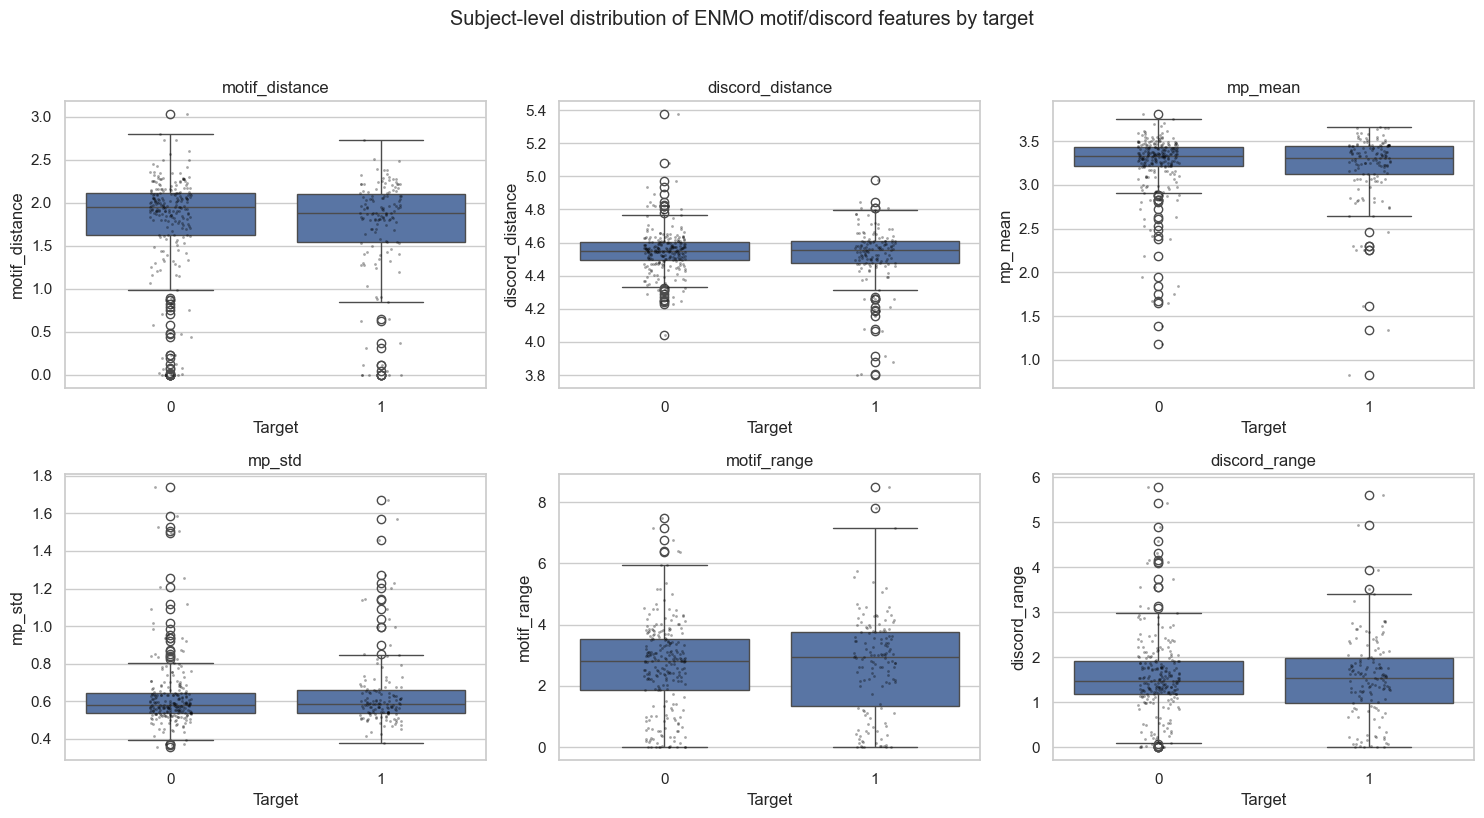

In [18]:
# ============================================================
# Cell 12 - Subject-level comparison and visualization
# ============================================================

from scipy.stats import mannwhitneyu, ks_2samp

# ------------------------------------------------------------
# Features to compare at subject level
# ------------------------------------------------------------
subject_features_to_compare = [
    "motif_distance",
    "discord_distance",
    "mp_mean",
    "mp_std",
    "motif_range",
    "discord_range",
    "motif_std",
    "discord_std",
    "motif_start",
    "discord_start"
]

subject_features_to_compare = [
    col for col in subject_features_to_compare
    if col in subject_motif_discord_df.columns
]

# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------
def cohen_d(x0, x1):
    """
    Cohen's d for two independent samples.
    Positive values mean that target 1 has a larger mean than target 0.
    """
    x0 = np.asarray(x0, dtype=float)
    x1 = np.asarray(x1, dtype=float)

    n0 = len(x0)
    n1 = len(x1)

    s0 = np.var(x0, ddof=1)
    s1 = np.var(x1, ddof=1)

    pooled_std = np.sqrt(((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2))

    if pooled_std == 0:
        return np.nan

    return (np.mean(x1) - np.mean(x0)) / pooled_std


def rank_biserial_from_u(u_stat, n0, n1):
    """
    Rank-biserial correlation derived from the Mann-Whitney U statistic.
    Values close to 0 indicate strong distributional overlap.
    """
    return (2 * u_stat / (n0 * n1)) - 1


# ------------------------------------------------------------
# Statistical comparison at subject level
# ------------------------------------------------------------
subject_comparison_rows = []

for feature in subject_features_to_compare:
    x0 = subject_motif_discord_df.loc[
        subject_motif_discord_df["target"] == 0, feature
    ].dropna()

    x1 = subject_motif_discord_df.loc[
        subject_motif_discord_df["target"] == 1, feature
    ].dropna()

    mw = mannwhitneyu(x0, x1, alternative="two-sided")
    ks = ks_2samp(x0, x1)

    subject_comparison_rows.append({
        "feature": feature,

        "mean_target_0": np.mean(x0),
        "mean_target_1": np.mean(x1),
        "median_target_0": np.median(x0),
        "median_target_1": np.median(x1),

        "mean_diff_1_minus_0": np.mean(x1) - np.mean(x0),
        "median_diff_1_minus_0": np.median(x1) - np.median(x0),

        "cohen_d_1_vs_0": cohen_d(x0, x1),
        "rank_biserial": rank_biserial_from_u(mw.statistic, len(x0), len(x1)),

        "mannwhitney_pvalue": mw.pvalue,
        "ks_pvalue": ks.pvalue
    })

subject_comparison_df = pd.DataFrame(subject_comparison_rows)

subject_comparison_df["abs_cohen_d"] = subject_comparison_df["cohen_d_1_vs_0"].abs()
subject_comparison_df = subject_comparison_df.sort_values("abs_cohen_d", ascending=False)

print("Subject-level comparison of motif/discord features:")
display(subject_comparison_df)

# ------------------------------------------------------------
# Boxplots for the main subject-level features
# ------------------------------------------------------------
subject_plot_features = [
    "motif_distance",
    "discord_distance",
    "mp_mean",
    "mp_std",
    "motif_range",
    "discord_range"
]

subject_plot_features = [
    col for col in subject_plot_features
    if col in subject_motif_discord_df.columns
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feature in zip(axes, subject_plot_features):
    sns.boxplot(
        data=subject_motif_discord_df,
        x="target",
        y=feature,
        ax=ax
    )
    sns.stripplot(
        data=subject_motif_discord_df,
        x="target",
        y=feature,
        ax=ax,
        color="black",
        alpha=0.35,
        size=2,
        jitter=True
    )

    ax.set_title(feature)
    ax.set_xlabel("Target")
    ax.set_ylabel(feature)

for ax in axes[len(subject_plot_features):]:
    ax.axis("off")

plt.suptitle("Subject-level distribution of ENMO motif/discord features by target", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# Cell 13 - Compact subject-level comparison table for the report
# ============================================================

# ------------------------------------------------------------
# Select the most interpretable features for the report
# ------------------------------------------------------------
report_features = [
    "motif_distance",
    "discord_distance",
    "mp_mean",
    "mp_std",
    "motif_range",
    "discord_range"
]

report_features = [
    col for col in report_features
    if col in subject_comparison_df["feature"].values
]

# ------------------------------------------------------------
# Build compact comparison table
# ------------------------------------------------------------
report_comparison_df = (
    subject_comparison_df[
        subject_comparison_df["feature"].isin(report_features)
    ]
    .copy()
)

report_comparison_df = report_comparison_df[
    [
        "feature",
        "mean_target_0",
        "mean_target_1",
        "median_target_0",
        "median_target_1",
        "mean_diff_1_minus_0",
        "cohen_d_1_vs_0",
        "rank_biserial",
        "mannwhitney_pvalue",
        "ks_pvalue"
    ]
]

# Round numerical columns for readability
numeric_cols = report_comparison_df.select_dtypes(include=[np.number]).columns
report_comparison_df[numeric_cols] = report_comparison_df[numeric_cols].round(4)

# Sort in the same order as report_features
report_comparison_df["feature"] = pd.Categorical(
    report_comparison_df["feature"],
    categories=report_features,
    ordered=True
)

report_comparison_df = report_comparison_df.sort_values("feature").reset_index(drop=True)

print("Compact subject-level comparison table:")
display(report_comparison_df)

# ------------------------------------------------------------
# Optional: save table for later use
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

report_comparison_path = OUTPUT_DIR / "subject_level_motif_discord_comparison.csv"
report_comparison_df.to_csv(report_comparison_path, index=False)

print(f"\nSaved compact comparison table to: {report_comparison_path}")

Compact subject-level comparison table:


,feature,mean_target_0,mean_target_1,median_target_0,median_target_1,mean_diff_1_minus_0,cohen_d_1_vs_0,rank_biserial,mannwhitney_pvalue,ks_pvalue
0,motif_distance,1.7761,1.7283,1.9465,1.8764,-0.0478,-0.0798,0.0801,0.1953,0.0769
1,discord_distance,4.5504,4.5213,4.5517,4.5549,-0.0291,-0.1892,0.0215,0.7281,0.5733
2,mp_mean,3.2446,3.2083,3.3358,3.3134,-0.0363,-0.0944,0.0485,0.4332,0.6181
3,mp_std,0.6294,0.6461,0.5802,0.5850,0.0167,0.0842,-0.0184,0.7669,0.9460
4,motif_range,2.6291,2.7162,2.8142,2.9328,0.0871,0.0566,-0.0473,0.4443,0.6132
5,discord_range,1.5924,1.5334,1.4779,1.5457,-0.0590,-0.0640,0.0104,0.8664,0.4758



Saved compact comparison table to: outputs/motifs_discords/subject_level_motif_discord_comparison.csv


Representative windows selected:
Target=0 | series_index=3109 | subject_id=1235 | motif_distance=2.0408 | discord_distance=4.5598
Target=1 | series_index=3716 | subject_id=379 | motif_distance=1.9578 | discord_distance=4.5584


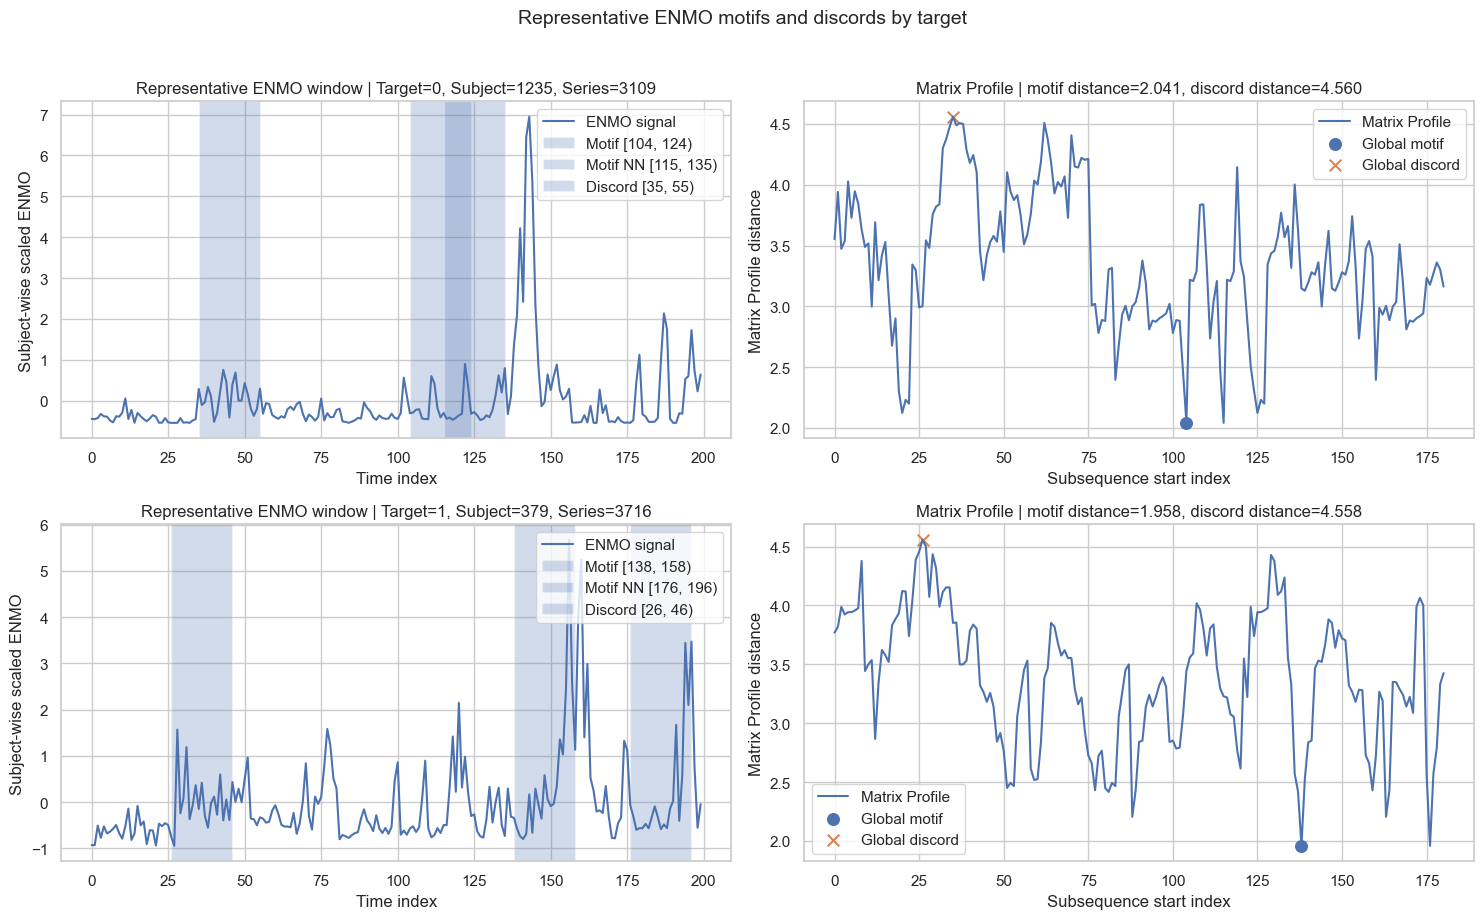

In [20]:
# ============================================================
# Cell 14 - Representative motif/discord examples by target
# ============================================================

def select_representative_window_by_target(
    features_df,
    target_value,
    feature_cols=("motif_distance", "discord_distance", "mp_mean", "mp_std")
):
    """
    Select a representative time-series window for a given target class.

    The representative window is chosen as the one whose motif/discord features
    are closest to the class median profile.

    Parameters
    ----------
    features_df : pd.DataFrame
        Window-level motif/discord feature dataframe.
    target_value : int
        Target class to select.
    feature_cols : tuple
        Features used to define representativeness.

    Returns
    -------
    int
        Selected series index.
    """

    class_df = features_df[features_df["target"] == target_value].copy()

    if class_df.empty:
        raise ValueError(f"No windows found for target={target_value}.")

    feature_cols = [
        col for col in feature_cols
        if col in class_df.columns
    ]

    medians = class_df[feature_cols].median()
    iqrs = class_df[feature_cols].quantile(0.75) - class_df[feature_cols].quantile(0.25)

    # Avoid division by zero
    iqrs = iqrs.replace(0, 1.0)

    standardized_distance = (
        (class_df[feature_cols] - medians).abs() / iqrs
    ).sum(axis=1)

    selected_row = class_df.loc[standardized_distance.idxmin()]

    return int(selected_row["series_index"])


def compute_matrix_profile_for_window(series_index, signal_col="enmo", m=20):
    """
    Compute Matrix Profile, global motif and global discord for one window.
    Overlap between motif and discord is allowed.
    """

    ts_df = CMI_timeseries_motif[series_index].copy()
    x_local = ts_df[signal_col].to_numpy(dtype=float)

    mp_local = stumpy.stump(x_local, m=m)
    mp_values_local = mp_local[:, 0].astype(float)
    mp_indices_local = mp_local[:, 1].astype(int)

    motif_start_local = int(np.argmin(mp_values_local))
    motif_nn_local = int(mp_indices_local[motif_start_local])
    motif_distance_local = float(mp_values_local[motif_start_local])

    discord_start_local = int(np.argmax(mp_values_local))
    discord_distance_local = float(mp_values_local[discord_start_local])

    return {
        "ts_df": ts_df,
        "x": x_local,
        "mp_values": mp_values_local,
        "mp_indices": mp_indices_local,
        "subject_id": ts_df[id_col].iloc[0],
        "target": int(ts_df[target_col].iloc[0]),
        "motif_start": motif_start_local,
        "motif_nn_start": motif_nn_local,
        "motif_distance": motif_distance_local,
        "discord_start": discord_start_local,
        "discord_distance": discord_distance_local
    }


# ------------------------------------------------------------
# Select one representative window per target
# ------------------------------------------------------------
representative_indices = {}

for target_value in sorted(motif_discord_valid_df["target"].unique()):
    representative_indices[target_value] = select_representative_window_by_target(
        features_df=motif_discord_valid_df,
        target_value=target_value
    )

print("Representative windows selected:")
for target_value, idx in representative_indices.items():
    row = motif_discord_valid_df.loc[
        motif_discord_valid_df["series_index"] == idx
    ].iloc[0]

    print(
        f"Target={target_value} | "
        f"series_index={idx} | "
        f"subject_id={row['subject_id']} | "
        f"motif_distance={row['motif_distance']:.4f} | "
        f"discord_distance={row['discord_distance']:.4f}"
    )


# ------------------------------------------------------------
# Plot representative motif/discord examples
# ------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=len(representative_indices),
    ncols=2,
    figsize=(15, 4.5 * len(representative_indices))
)

if len(representative_indices) == 1:
    axes = np.array([axes])

for row_idx, (target_value, series_index) in enumerate(representative_indices.items()):

    result = compute_matrix_profile_for_window(
        series_index=series_index,
        signal_col=signal_to_analyze,
        m=m
    )

    x_local = result["x"]
    mp_values_local = result["mp_values"]

    motif_start_local = result["motif_start"]
    motif_nn_local = result["motif_nn_start"]
    discord_start_local = result["discord_start"]

    # --------------------------------------------------------
    # Left plot: ENMO signal with motif/discord regions
    # --------------------------------------------------------
    ax_signal = axes[row_idx, 0]

    ax_signal.plot(x_local, linewidth=1.5, label="ENMO signal")

    ax_signal.axvspan(
        motif_start_local,
        motif_start_local + m,
        alpha=0.25,
        label=f"Motif [{motif_start_local}, {motif_start_local + m})"
    )

    ax_signal.axvspan(
        motif_nn_local,
        motif_nn_local + m,
        alpha=0.25,
        label=f"Motif NN [{motif_nn_local}, {motif_nn_local + m})"
    )

    ax_signal.axvspan(
        discord_start_local,
        discord_start_local + m,
        alpha=0.25,
        label=f"Discord [{discord_start_local}, {discord_start_local + m})"
    )

    ax_signal.set_title(
        f"Representative ENMO window | Target={target_value}, "
        f"Subject={result['subject_id']}, Series={series_index}"
    )
    ax_signal.set_xlabel("Time index")
    ax_signal.set_ylabel("Subject-wise scaled ENMO")
    ax_signal.legend(loc="upper right")
    ax_signal.grid(True)

    # --------------------------------------------------------
    # Right plot: Matrix Profile
    # --------------------------------------------------------
    ax_mp = axes[row_idx, 1]

    ax_mp.plot(mp_values_local, linewidth=1.5, label="Matrix Profile")

    ax_mp.scatter(
        motif_start_local,
        result["motif_distance"],
        s=70,
        marker="o",
        label="Global motif"
    )

    ax_mp.scatter(
        discord_start_local,
        result["discord_distance"],
        s=70,
        marker="x",
        label="Global discord"
    )

    ax_mp.set_title(
        f"Matrix Profile | motif distance={result['motif_distance']:.3f}, "
        f"discord distance={result['discord_distance']:.3f}"
    )
    ax_mp.set_xlabel("Subsequence start index")
    ax_mp.set_ylabel("Matrix Profile distance")
    ax_mp.legend(loc="best")
    ax_mp.grid(True)

plt.suptitle(
    "Representative ENMO motifs and discords by target",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
plt.show()

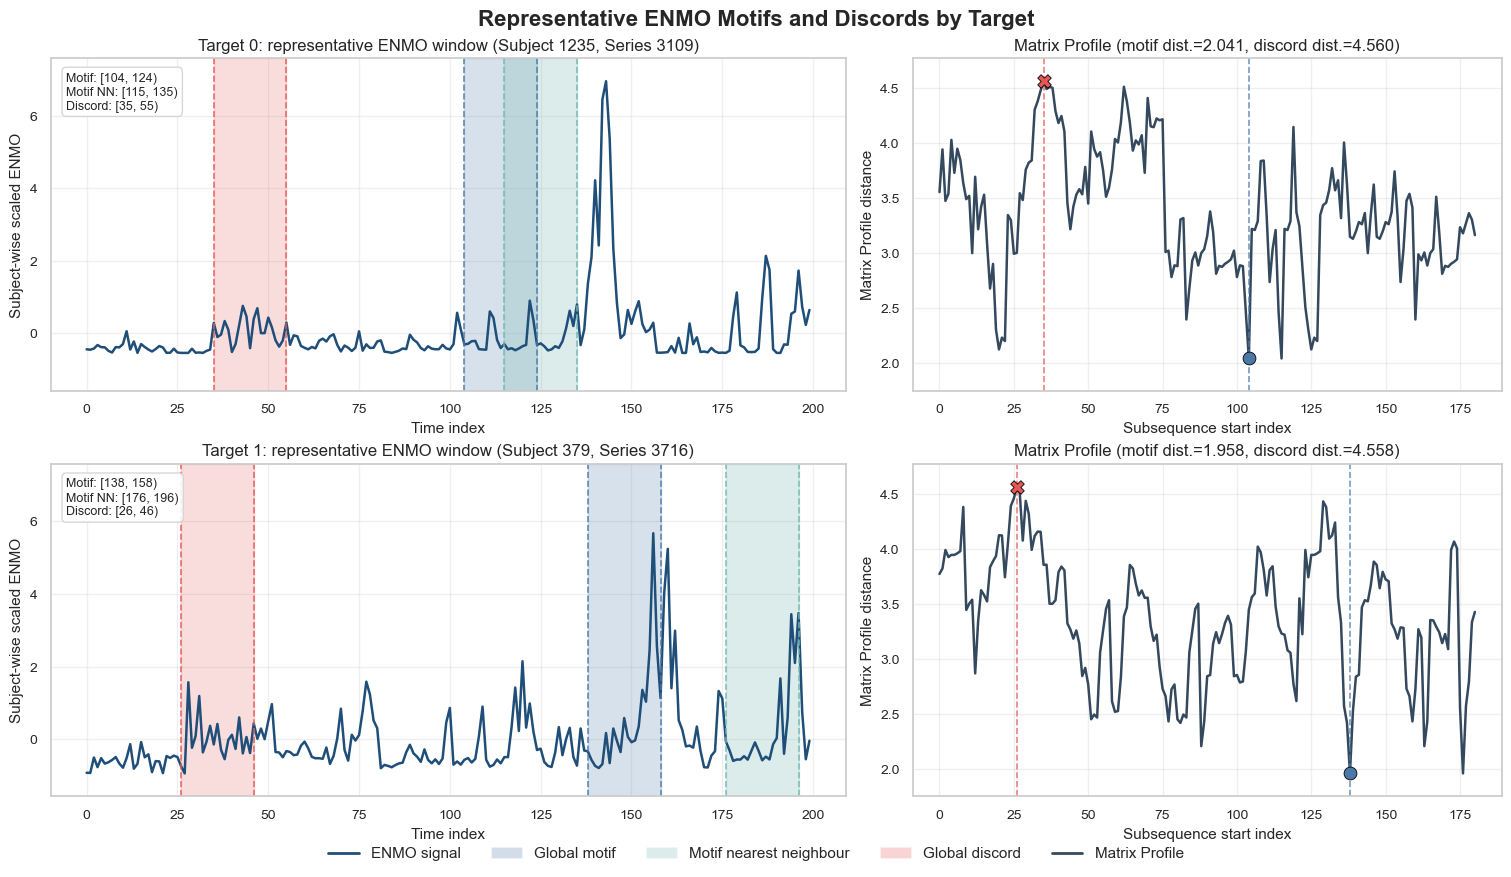

Saved figure to: outputs/motifs_discords/representative_enmo_motifs_discords_by_target.png


In [21]:
# ============================================================
# Cell 15 - Cleaner representative motif/discord visualization
# ============================================================

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path

# ------------------------------------------------------------
# Recompute results for selected representative windows
# ------------------------------------------------------------
targets = sorted(representative_indices.keys())

representative_results = {}

for target_value in targets:
    series_index = representative_indices[target_value]
    representative_results[target_value] = compute_matrix_profile_for_window(
        series_index=series_index,
        signal_col=signal_to_analyze,
        m=m
    )

# ------------------------------------------------------------
# Global axis limits for visual comparability
# ------------------------------------------------------------
all_signal_values = np.concatenate([
    representative_results[t]["x"]
    for t in targets
])

all_mp_values = np.concatenate([
    representative_results[t]["mp_values"]
    for t in targets
])

signal_y_margin = 0.08 * (all_signal_values.max() - all_signal_values.min())
mp_y_margin = 0.08 * (all_mp_values.max() - all_mp_values.min())

signal_ylim = (
    all_signal_values.min() - signal_y_margin,
    all_signal_values.max() + signal_y_margin
)

mp_ylim = (
    all_mp_values.min() - mp_y_margin,
    all_mp_values.max() + mp_y_margin
)

# ------------------------------------------------------------
# Visual settings
# ------------------------------------------------------------
signal_color = "#1f4e79"
mp_color = "#34495e"
motif_color = "#4C78A8"
motif_nn_color = "#72B7B2"
discord_color = "#E45756"

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=len(targets),
    ncols=2,
    figsize=(15, 4.2 * len(targets)),
    gridspec_kw={"width_ratios": [1.35, 1.0]},
    constrained_layout=True
)

if len(targets) == 1:
    axes = np.array([axes])

for row_idx, target_value in enumerate(targets):

    result = representative_results[target_value]

    x_local = result["x"]
    mp_values_local = result["mp_values"]

    subject_id = result["subject_id"]
    series_index = representative_indices[target_value]

    motif_start = result["motif_start"]
    motif_nn_start = result["motif_nn_start"]
    discord_start = result["discord_start"]

    motif_distance = result["motif_distance"]
    discord_distance = result["discord_distance"]

    # ========================================================
    # Left panel: ENMO signal with highlighted regions
    # ========================================================
    ax_signal = axes[row_idx, 0]

    ax_signal.plot(
        x_local,
        color=signal_color,
        linewidth=1.8
    )

    # Highlight motif, motif nearest neighbour and discord
    ax_signal.axvspan(
        motif_start,
        motif_start + m,
        color=motif_color,
        alpha=0.22
    )

    ax_signal.axvspan(
        motif_nn_start,
        motif_nn_start + m,
        color=motif_nn_color,
        alpha=0.25
    )

    ax_signal.axvspan(
        discord_start,
        discord_start + m,
        color=discord_color,
        alpha=0.20
    )

    # Add vertical boundaries
    for start, color in [
        (motif_start, motif_color),
        (motif_nn_start, motif_nn_color),
        (discord_start, discord_color)
    ]:
        ax_signal.axvline(start, color=color, linewidth=1.2, linestyle="--", alpha=0.85)
        ax_signal.axvline(start + m, color=color, linewidth=1.2, linestyle="--", alpha=0.85)

    ax_signal.set_title(
        f"Target {target_value}: representative ENMO window "
        f"(Subject {subject_id}, Series {series_index})"
    )
    ax_signal.set_xlabel("Time index")
    ax_signal.set_ylabel("Subject-wise scaled ENMO")
    ax_signal.set_ylim(signal_ylim)
    ax_signal.grid(True, alpha=0.30)

    # Add compact text box
    text_box = (
        f"Motif: [{motif_start}, {motif_start + m})\n"
        f"Motif NN: [{motif_nn_start}, {motif_nn_start + m})\n"
        f"Discord: [{discord_start}, {discord_start + m})"
    )

    ax_signal.text(
        0.02,
        0.96,
        text_box,
        transform=ax_signal.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.90
        )
    )

    # ========================================================
    # Right panel: Matrix Profile
    # ========================================================
    ax_mp = axes[row_idx, 1]

    ax_mp.plot(
        mp_values_local,
        color=mp_color,
        linewidth=1.8
    )

    ax_mp.scatter(
        motif_start,
        motif_distance,
        color=motif_color,
        s=85,
        marker="o",
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    ax_mp.scatter(
        discord_start,
        discord_distance,
        color=discord_color,
        s=95,
        marker="X",
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    # Vertical reference lines on MP
    ax_mp.axvline(
        motif_start,
        color=motif_color,
        linestyle="--",
        linewidth=1.2,
        alpha=0.75
    )

    ax_mp.axvline(
        discord_start,
        color=discord_color,
        linestyle="--",
        linewidth=1.2,
        alpha=0.75
    )

    ax_mp.set_title(
        f"Matrix Profile "
        f"(motif dist.={motif_distance:.3f}, discord dist.={discord_distance:.3f})"
    )
    ax_mp.set_xlabel("Subsequence start index")
    ax_mp.set_ylabel("Matrix Profile distance")
    ax_mp.set_ylim(mp_ylim)
    ax_mp.grid(True, alpha=0.30)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=signal_color, linewidth=2, label="ENMO signal"),
    Patch(facecolor=motif_color, alpha=0.25, label="Global motif"),
    Patch(facecolor=motif_nn_color, alpha=0.25, label="Motif nearest neighbour"),
    Patch(facecolor=discord_color, alpha=0.25, label="Global discord"),
    Line2D([0], [0], color=mp_color, linewidth=2, label="Matrix Profile"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.035)
)

fig.suptitle(
    "Representative ENMO Motifs and Discords by Target",
    fontsize=16,
    fontweight="bold"
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_path = OUTPUT_DIR / "representative_enmo_motifs_discords_by_target.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved figure to: {output_path}")

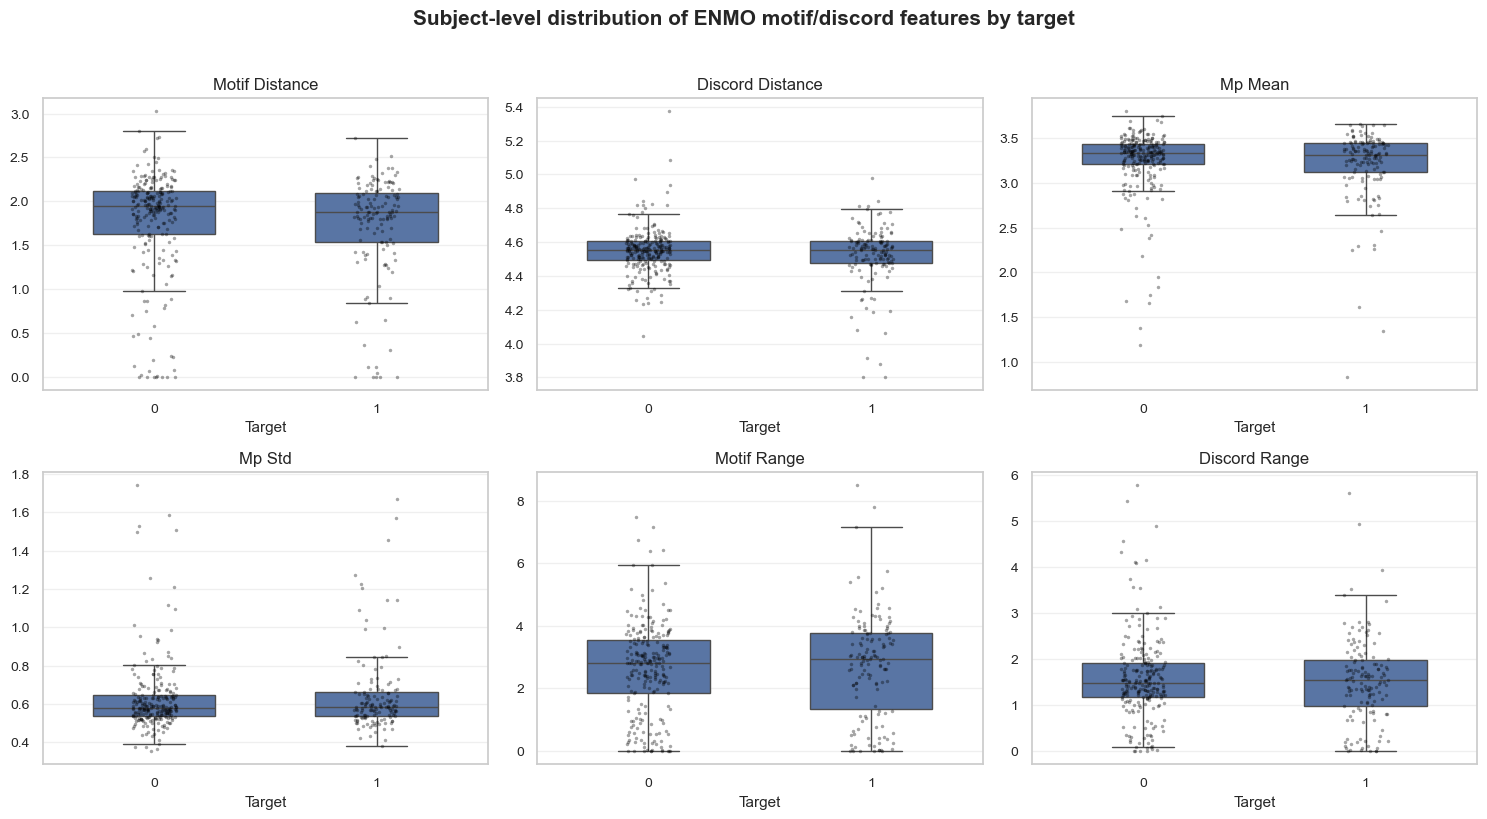

Saved subject-level boxplot figure to: outputs/motifs_discords/subject_level_motif_discord_boxplots.png
Saved LaTeX comparison table to: outputs/motifs_discords/subject_level_motif_discord_comparison.tex

LaTeX table preview:
\begin{table}
\caption{Subject-level comparison of ENMO motif/discord features between target classes.}
\label{tab:subject-level-motif-discord-comparison}
\begin{tabular}{lrrrrrrrrr}
\toprule
Feature & Mean 0 & Mean 1 & Median 0 & Median 1 & Mean diff. & Cohen's $d$ & Rank-biserial & MW $p$-value & KS $p$-value \\
\midrule
Motif Distance & 1.7761 & 1.7283 & 1.9465 & 1.8764 & -0.0478 & -0.0798 & 0.0801 & 0.1953 & 0.0769 \\
Discord Distance & 4.5504 & 4.5213 & 4.5517 & 4.5549 & -0.0291 & -0.1892 & 0.0215 & 0.7281 & 0.5733 \\
Mp Mean & 3.2446 & 3.2083 & 3.3358 & 3.3134 & -0.0363 & -0.0944 & 0.0485 & 0.4332 & 0.6181 \\
Mp Std & 0.6294 & 0.6461 & 0.5802 & 0.5850 & 0.0167 & 0.0842 & -0.0184 & 0.7669 & 0.9460 \\
Motif Range & 2.6291 & 2.7162 & 2.8142 & 2.9328 & 0.0871 & 

In [22]:
# ============================================================
# Cell 16 - Save report-ready outputs for motifs/discords
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Features to show in the report
# ------------------------------------------------------------
report_plot_features = [
    "motif_distance",
    "discord_distance",
    "mp_mean",
    "mp_std",
    "motif_range",
    "discord_range"
]

report_plot_features = [
    col for col in report_plot_features
    if col in subject_motif_discord_df.columns
]

# ------------------------------------------------------------
# Cleaner subject-level boxplot figure
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feature in zip(axes, report_plot_features):
    sns.boxplot(
        data=subject_motif_discord_df,
        x="target",
        y=feature,
        ax=ax,
        width=0.55,
        showfliers=False
    )

    sns.stripplot(
        data=subject_motif_discord_df,
        x="target",
        y=feature,
        ax=ax,
        color="black",
        alpha=0.35,
        size=2.5,
        jitter=True
    )

    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Target")
    ax.set_ylabel("")
    ax.grid(True, axis="y", alpha=0.30)

for ax in axes[len(report_plot_features):]:
    ax.axis("off")

fig.suptitle(
    "Subject-level distribution of ENMO motif/discord features by target",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

boxplot_path = OUTPUT_DIR / "subject_level_motif_discord_boxplots.png"

plt.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved subject-level boxplot figure to: {boxplot_path}")

# ------------------------------------------------------------
# Create a cleaner table for the report
# ------------------------------------------------------------
latex_table_df = report_comparison_df.copy()

# Rename columns for readability in the report
latex_table_df = latex_table_df.rename(columns={
    "feature": "Feature",
    "mean_target_0": "Mean 0",
    "mean_target_1": "Mean 1",
    "median_target_0": "Median 0",
    "median_target_1": "Median 1",
    "mean_diff_1_minus_0": "Mean diff.",
    "cohen_d_1_vs_0": "Cohen's $d$",
    "rank_biserial": "Rank-biserial",
    "mannwhitney_pvalue": "MW $p$-value",
    "ks_pvalue": "KS $p$-value"
})

# Make feature names more readable
latex_table_df["Feature"] = (
    latex_table_df["Feature"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.title()
)

# Export LaTeX table
latex_table_path = OUTPUT_DIR / "subject_level_motif_discord_comparison.tex"

latex_code = latex_table_df.to_latex(
    index=False,
    escape=False,
    float_format="%.4f",
    caption=(
        "Subject-level comparison of ENMO motif/discord features between target classes."
    ),
    label="tab:subject-level-motif-discord-comparison",
    column_format="lrrrrrrrrr"
)

with open(latex_table_path, "w") as f:
    f.write(latex_code)

print(f"Saved LaTeX comparison table to: {latex_table_path}")

print("\nLaTeX table preview:")
print(latex_code)

## Relationship with Shapelets

In [23]:
# ============================================================
# Cell 17 - Prepare ENMO data for shapelet mining
# ============================================================

# ------------------------------------------------------------
# Build compact arrays for ENMO windows
# ------------------------------------------------------------
X_enmo_list = []
y_enmo_list = []
subject_enmo_list = []
series_index_list = []

for series_index, ts_df in enumerate(CMI_timeseries_motif):
    x_local = ts_df[signal_to_analyze].to_numpy(dtype=float)
    
    if len(x_local) != len(x):
        raise ValueError(
            f"Inconsistent time-series length at series_index={series_index}: "
            f"expected {len(x)}, got {len(x_local)}"
        )
    
    if not np.all(np.isfinite(x_local)):
        continue
    
    X_enmo_list.append(x_local)
    y_enmo_list.append(int(ts_df[target_col].iloc[0]))
    subject_enmo_list.append(ts_df[id_col].iloc[0])
    series_index_list.append(series_index)

X_enmo = np.vstack(X_enmo_list)
y_enmo = np.asarray(y_enmo_list, dtype=int)
subject_enmo = np.asarray(subject_enmo_list)
series_index_array = np.asarray(series_index_list, dtype=int)

print("ENMO data prepared for shapelet mining.")
print(f"X_enmo shape: {X_enmo.shape}")
print(f"y_enmo shape: {y_enmo.shape}")
print(f"Number of unique subjects: {pd.Series(subject_enmo).nunique()}")

# ------------------------------------------------------------
# Metadata dataframe
# ------------------------------------------------------------
shapelet_metadata_df = pd.DataFrame({
    "row_index": np.arange(len(X_enmo)),
    "series_index": series_index_array,
    "subject_id": subject_enmo,
    "target": y_enmo
})

print("\nWindow-level target distribution:")
display(shapelet_metadata_df["target"].value_counts().sort_index())

print("\nSubject-level target distribution:")
display(
    shapelet_metadata_df
    .drop_duplicates("subject_id")["target"]
    .value_counts()
    .sort_index()
)

print("\nNumber of windows per subject:")
display(
    shapelet_metadata_df
    .groupby("subject_id")["series_index"]
    .count()
    .describe()
)

display(shapelet_metadata_df.head())

# ------------------------------------------------------------
# Build a subject-balanced candidate-source set
# ------------------------------------------------------------
# Shapelet candidates will be sampled from this set.
# We use a subject-balanced set to avoid over-representing subjects
# with many windows.
# ------------------------------------------------------------

N_SUBJECTS_PER_CLASS_FOR_CANDIDATES = 100
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

subject_target_df = (
    shapelet_metadata_df
    .drop_duplicates("subject_id")[["subject_id", "target"]]
    .reset_index(drop=True)
)

selected_candidate_subjects = []

for target_value in sorted(subject_target_df["target"].unique()):
    class_subjects = subject_target_df.loc[
        subject_target_df["target"] == target_value,
        "subject_id"
    ].to_numpy()
    
    n_to_sample = min(N_SUBJECTS_PER_CLASS_FOR_CANDIDATES, len(class_subjects))
    
    sampled_subjects = rng.choice(
        class_subjects,
        size=n_to_sample,
        replace=False
    )
    
    selected_candidate_subjects.extend(sampled_subjects)

selected_candidate_subjects = np.asarray(selected_candidate_subjects)

# For each selected subject, choose one random window as candidate source
candidate_source_rows = []

for subject_id_value in selected_candidate_subjects:
    subject_rows = shapelet_metadata_df.loc[
        shapelet_metadata_df["subject_id"] == subject_id_value,
        "row_index"
    ].to_numpy()
    
    selected_row = rng.choice(subject_rows, size=1, replace=False)[0]
    candidate_source_rows.append(selected_row)

candidate_source_rows = np.asarray(candidate_source_rows, dtype=int)

candidate_source_df = shapelet_metadata_df.loc[
    candidate_source_rows
].copy().reset_index(drop=True)

print("\nCandidate-source set for shapelet extraction:")
print(f"Number of candidate-source windows: {len(candidate_source_df)}")

display(candidate_source_df["target"].value_counts().sort_index())
display(candidate_source_df.head())

ENMO data prepared for shapelet mining.
X_enmo shape: (4310, 200)
y_enmo shape: (4310,)
Number of unique subjects: 375

Window-level target distribution:


target
0    2888
1    1422
Name: count, dtype: int64


Subject-level target distribution:


target
0    236
1    139
Name: count, dtype: int64


Number of windows per subject:


count    375.000000
mean      11.493333
std       10.892245
min        1.000000
25%        1.000000
50%        8.000000
75%       21.000000
max       36.000000
Name: series_index, dtype: float64

,row_index,series_index,subject_id,target
0,0,0,2265,0
1,1,1,3042,1
2,2,2,1647,1
3,3,3,736,0
4,4,4,1044,0



Candidate-source set for shapelet extraction:
Number of candidate-source windows: 200


target
0    100
1    100
Name: count, dtype: int64

,row_index,series_index,subject_id,target
0,2955,2955,1394,0
1,2933,2933,1524,0
2,2905,2905,282,0
3,725,725,3632,0
4,1986,1986,3570,0


In [24]:
# ============================================================
# Cell 18 - Mine supervised ENMO shapelets
# ============================================================

from numpy.lib.stride_tricks import sliding_window_view
from scipy.stats import mannwhitneyu
import time

# ------------------------------------------------------------
# Shapelet mining configuration
# ------------------------------------------------------------
SHAPELET_LENGTHS = [10, 20, 30, 40]
N_CANDIDATES_PER_LENGTH = 80
N_EVAL_SUBJECTS_PER_CLASS = 120
TOP_N_SHAPELETS = 20
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

# ------------------------------------------------------------
# Utility: z-normalization
# ------------------------------------------------------------
def z_normalize_array(a, axis=None, eps=1e-8):
    """
    Z-normalize an array along a given axis.
    """
    a = np.asarray(a, dtype=float)
    mean = np.mean(a, axis=axis, keepdims=True)
    std = np.std(a, axis=axis, keepdims=True)

    return (a - mean) / np.maximum(std, eps)


def min_shapelet_distance_to_series(shapelet_z, series):
    """
    Compute the minimum z-normalized Euclidean distance between a shapelet
    and all subsequences of equal length in one time series.

    Parameters
    ----------
    shapelet_z : np.ndarray
        Z-normalized candidate shapelet.
    series : np.ndarray
        One ENMO time series.

    Returns
    -------
    float
        Minimum normalized Euclidean distance.
    """
    L = len(shapelet_z)

    subsequences = sliding_window_view(series, window_shape=L)
    subsequences_z = z_normalize_array(subsequences, axis=1)

    distances = np.linalg.norm(subsequences_z - shapelet_z, axis=1)

    # Normalize by sqrt(L), so distances are more comparable across lengths
    return float(np.min(distances) / np.sqrt(L))


def compute_shapelet_distance_vector(shapelet_z, X_matrix):
    """
    Compute the shapelet distance vector for many time series.
    """
    distances = np.empty(X_matrix.shape[0], dtype=float)

    for i in range(X_matrix.shape[0]):
        distances[i] = min_shapelet_distance_to_series(
            shapelet_z=shapelet_z,
            series=X_matrix[i]
        )

    return distances


def cohen_d_binary(x0, x1):
    """
    Cohen's d for two independent samples.
    Positive values mean class 1 has larger values than class 0.
    """
    x0 = np.asarray(x0, dtype=float)
    x1 = np.asarray(x1, dtype=float)

    n0 = len(x0)
    n1 = len(x1)

    s0 = np.var(x0, ddof=1)
    s1 = np.var(x1, ddof=1)

    pooled = np.sqrt(((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2))

    if pooled == 0:
        return 0.0

    return float((np.mean(x1) - np.mean(x0)) / pooled)


# ------------------------------------------------------------
# Build a subject-balanced evaluation set
# ------------------------------------------------------------
subject_target_df = (
    shapelet_metadata_df
    .drop_duplicates("subject_id")[["subject_id", "target"]]
    .reset_index(drop=True)
)

eval_subjects = []

for target_value in sorted(subject_target_df["target"].unique()):
    class_subjects = subject_target_df.loc[
        subject_target_df["target"] == target_value,
        "subject_id"
    ].to_numpy()

    n_to_sample = min(N_EVAL_SUBJECTS_PER_CLASS, len(class_subjects))

    sampled_subjects = rng.choice(
        class_subjects,
        size=n_to_sample,
        replace=False
    )

    eval_subjects.extend(sampled_subjects)

eval_rows = []

for subject_id_value in eval_subjects:
    subject_rows = shapelet_metadata_df.loc[
        shapelet_metadata_df["subject_id"] == subject_id_value,
        "row_index"
    ].to_numpy()

    selected_row = rng.choice(subject_rows, size=1, replace=False)[0]
    eval_rows.append(selected_row)

eval_rows = np.asarray(eval_rows, dtype=int)

X_eval = X_enmo[eval_rows]
y_eval = y_enmo[eval_rows]

print("Shapelet evaluation set:")
print(f"X_eval shape: {X_eval.shape}")
print("Target distribution:")
display(pd.Series(y_eval).value_counts().sort_index())

# ------------------------------------------------------------
# Generate candidate shapelets from subject-balanced source windows
# ------------------------------------------------------------
candidate_rows = []

for L in SHAPELET_LENGTHS:
    for _ in range(N_CANDIDATES_PER_LENGTH):
        source_row = int(rng.choice(candidate_source_rows))

        source_series = X_enmo[source_row]

        max_start = len(source_series) - L
        start = int(rng.integers(0, max_start + 1))

        shapelet_raw = source_series[start:start + L]
        shapelet_z = z_normalize_array(shapelet_raw)

        candidate_rows.append({
            "length": L,
            "source_row": source_row,
            "source_series_index": int(shapelet_metadata_df.loc[source_row, "series_index"]),
            "source_subject_id": shapelet_metadata_df.loc[source_row, "subject_id"],
            "source_target": int(shapelet_metadata_df.loc[source_row, "target"]),
            "start": start,
            "values": shapelet_z
        })

print(f"\nNumber of candidate shapelets generated: {len(candidate_rows)}")

# ------------------------------------------------------------
# Score candidate shapelets
# ------------------------------------------------------------
start_time = time.time()

scored_shapelets = []

for candidate_id, candidate in tqdm(
    enumerate(candidate_rows),
    total=len(candidate_rows),
    desc="Scoring shapelet candidates"
):
    shapelet_z = candidate["values"]

    distance_vector = compute_shapelet_distance_vector(
        shapelet_z=shapelet_z,
        X_matrix=X_eval
    )

    d0 = distance_vector[y_eval == 0]
    d1 = distance_vector[y_eval == 1]

    effect = cohen_d_binary(d0, d1)

    try:
        mw = mannwhitneyu(d0, d1, alternative="two-sided")
        pvalue = float(mw.pvalue)
    except Exception:
        pvalue = np.nan

    scored_shapelets.append({
        "candidate_id": candidate_id,
        "length": candidate["length"],
        "source_row": candidate["source_row"],
        "source_series_index": candidate["source_series_index"],
        "source_subject_id": candidate["source_subject_id"],
        "source_target": candidate["source_target"],
        "start": candidate["start"],
        "score_abs_cohen_d": abs(effect),
        "cohen_d_1_vs_0": effect,
        "mean_distance_target_0": float(np.mean(d0)),
        "mean_distance_target_1": float(np.mean(d1)),
        "median_distance_target_0": float(np.median(d0)),
        "median_distance_target_1": float(np.median(d1)),
        "mannwhitney_pvalue": pvalue,
        "values": shapelet_z
    })

elapsed = time.time() - start_time

shapelets_df = pd.DataFrame(scored_shapelets)

# ------------------------------------------------------------
# Select top supervised shapelets
# ------------------------------------------------------------
top_shapelets_df = (
    shapelets_df
    .sort_values("score_abs_cohen_d", ascending=False)
    .head(TOP_N_SHAPELETS)
    .reset_index(drop=True)
)

print("\nShapelet candidate scoring completed.")
print(f"Elapsed time: {elapsed:.2f} seconds")

print("\nTop supervised ENMO shapelets:")
display(
    top_shapelets_df[
        [
            "candidate_id",
            "length",
            "source_series_index",
            "source_subject_id",
            "source_target",
            "start",
            "score_abs_cohen_d",
            "cohen_d_1_vs_0",
            "mean_distance_target_0",
            "mean_distance_target_1",
            "mannwhitney_pvalue"
        ]
    ]
)

# ------------------------------------------------------------
# Save shapelet results
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

shapelets_path = OUTPUT_DIR / "supervised_enmo_shapelets.pkl"

top_shapelets_df.to_pickle(shapelets_path)

print(f"\nSaved top shapelets to: {shapelets_path}")

Shapelet evaluation set:
X_eval shape: (240, 200)
Target distribution:


0    120
1    120
Name: count, dtype: int64


Number of candidate shapelets generated: 320


Scoring shapelet candidates:   0%|          | 0/320 [00:00<?, ?it/s]


Shapelet candidate scoring completed.
Elapsed time: 4.95 seconds

Top supervised ENMO shapelets:


,candidate_id,length,source_series_index,source_subject_id,source_target,start,score_abs_cohen_d,cohen_d_1_vs_0,mean_distance_target_0,mean_distance_target_1,mannwhitney_pvalue
0,142,20,1262,1721,1,46,0.346080,0.346080,0.659273,0.690716,0.019955
1,49,10,2157,1935,0,176,0.329265,-0.329265,0.392439,0.362278,0.011440
2,203,30,613,1267,1,120,0.316689,0.316689,0.765211,0.800799,0.015834
3,120,20,1306,924,0,126,0.298457,0.298457,0.932564,0.952053,0.038745
4,90,20,603,799,0,140,0.297644,0.297644,0.747849,0.774035,0.033628
5,278,40,2933,1524,0,66,0.292166,0.292166,0.841688,0.872231,0.039632
6,40,10,215,969,1,175,0.291246,0.291246,0.374402,0.392630,0.035537
7,311,40,1575,1412,0,35,0.290136,0.290136,0.953531,0.982707,0.047555
8,10,10,145,1205,1,105,0.285999,-0.285999,0.647374,0.615026,0.036359
9,281,40,41,1088,1,114,0.285656,-0.285656,0.930532,0.891681,0.057255



Saved top shapelets to: outputs/motifs_discords/supervised_enmo_shapelets.pkl


In [25]:
# ============================================================
# Cell 19 - Relationship between shapelets, motifs and discords
# ============================================================

from collections import defaultdict

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
TOP_SHAPELETS_TO_COMPARE = 20

unique_shapelet_lengths = sorted(top_shapelets_df["length"].unique())

print("Shapelet lengths to compare:")
print(unique_shapelet_lengths)

# ------------------------------------------------------------
# Utility: extract global motif and discord for a given length
# ------------------------------------------------------------
def extract_motif_discord_subsequences_for_length(series, L):
    """
    Extract global motif and global discord subsequences from one series
    using Matrix Profile with subsequence length L.

    Overlap between motifs and discords is allowed.
    """

    mp_local = stumpy.stump(series, m=L)

    mp_values_local = mp_local[:, 0].astype(float)
    mp_indices_local = mp_local[:, 1].astype(int)

    motif_start = int(np.argmin(mp_values_local))
    motif_nn_start = int(mp_indices_local[motif_start])
    discord_start = int(np.argmax(mp_values_local))

    motif = series[motif_start:motif_start + L]
    motif_nn = series[motif_nn_start:motif_nn_start + L]
    discord = series[discord_start:discord_start + L]

    return {
        "motif": z_normalize_array(motif),
        "motif_nn": z_normalize_array(motif_nn),
        "discord": z_normalize_array(discord),
        "motif_start": motif_start,
        "motif_nn_start": motif_nn_start,
        "discord_start": discord_start,
        "motif_distance": float(mp_values_local[motif_start]),
        "discord_distance": float(mp_values_local[discord_start])
    }


# ------------------------------------------------------------
# Build motif/discord reference sets from the balanced evaluation set
# ------------------------------------------------------------
reference_by_length = {}

for L in unique_shapelet_lengths:
    print(f"\nBuilding motif/discord reference set for L={L}...")

    motif_refs = []
    discord_refs = []
    reference_targets = []
    reference_rows = []
    reference_series_indices = []
    reference_subjects = []

    for local_i, row_index in tqdm(
        enumerate(eval_rows),
        total=len(eval_rows),
        desc=f"Reference extraction L={L}"
    ):
        series = X_enmo[row_index]
        target = int(y_enmo[row_index])

        result = extract_motif_discord_subsequences_for_length(
            series=series,
            L=L
        )

        # We include both members of the motif pair as motif references.
        motif_refs.append(result["motif"])
        motif_refs.append(result["motif_nn"])

        # The discord is kept as anomaly reference.
        discord_refs.append(result["discord"])

        # Metadata. For motifs, one window contributes two motif references.
        reference_targets.extend([target, target])
        reference_rows.extend([row_index, row_index])
        reference_series_indices.extend([
            int(shapelet_metadata_df.loc[row_index, "series_index"]),
            int(shapelet_metadata_df.loc[row_index, "series_index"])
        ])
        reference_subjects.extend([
            shapelet_metadata_df.loc[row_index, "subject_id"],
            shapelet_metadata_df.loc[row_index, "subject_id"]
        ])

    reference_by_length[L] = {
        "motifs": np.vstack(motif_refs),
        "discords": np.vstack(discord_refs),
        "motif_targets": np.asarray(reference_targets, dtype=int),
        "discord_targets": y_enmo[eval_rows].astype(int)
    }

    print(f"Motif references: {reference_by_length[L]['motifs'].shape}")
    print(f"Discord references: {reference_by_length[L]['discords'].shape}")


# ------------------------------------------------------------
# Compare each top shapelet with motif and discord reference sets
# ------------------------------------------------------------
relationship_rows = []

top_shapelets_for_comparison = top_shapelets_df.head(TOP_SHAPELETS_TO_COMPARE).copy()

for rank, (_, shp) in enumerate(top_shapelets_for_comparison.iterrows(), start=1):

    L = int(shp["length"])
    shapelet_values = np.asarray(shp["values"], dtype=float)
    shapelet_values = z_normalize_array(shapelet_values)

    motif_refs = reference_by_length[L]["motifs"]
    discord_refs = reference_by_length[L]["discords"]

    motif_targets = reference_by_length[L]["motif_targets"]
    discord_targets = reference_by_length[L]["discord_targets"]

    # Normalized Euclidean distances
    dist_to_motifs = np.linalg.norm(
        motif_refs - shapelet_values,
        axis=1
    ) / np.sqrt(L)

    dist_to_discords = np.linalg.norm(
        discord_refs - shapelet_values,
        axis=1
    ) / np.sqrt(L)

    # Class-specific distances
    dist_to_motifs_0 = dist_to_motifs[motif_targets == 0]
    dist_to_motifs_1 = dist_to_motifs[motif_targets == 1]

    dist_to_discords_0 = dist_to_discords[discord_targets == 0]
    dist_to_discords_1 = dist_to_discords[discord_targets == 1]

    mean_motif_distance = float(np.mean(dist_to_motifs))
    mean_discord_distance = float(np.mean(dist_to_discords))

    median_motif_distance = float(np.median(dist_to_motifs))
    median_discord_distance = float(np.median(dist_to_discords))

    min_motif_distance = float(np.min(dist_to_motifs))
    min_discord_distance = float(np.min(dist_to_discords))

    if mean_motif_distance < mean_discord_distance:
        closer_to_mean = "motifs"
    else:
        closer_to_mean = "discords"

    if min_motif_distance < min_discord_distance:
        closer_to_min = "motifs"
    else:
        closer_to_min = "discords"

    relationship_rows.append({
        "rank": rank,
        "candidate_id": int(shp["candidate_id"]),
        "length": L,
        "source_target": int(shp["source_target"]),
        "source_subject_id": shp["source_subject_id"],
        "source_series_index": int(shp["source_series_index"]),
        "source_start": int(shp["start"]),

        "shapelet_abs_cohen_d": float(shp["score_abs_cohen_d"]),
        "shapelet_cohen_d_1_vs_0": float(shp["cohen_d_1_vs_0"]),

        "mean_distance_to_motifs": mean_motif_distance,
        "mean_distance_to_discords": mean_discord_distance,
        "median_distance_to_motifs": median_motif_distance,
        "median_distance_to_discords": median_discord_distance,
        "min_distance_to_motifs": min_motif_distance,
        "min_distance_to_discords": min_discord_distance,

        "mean_discord_minus_motif": mean_discord_distance - mean_motif_distance,
        "median_discord_minus_motif": median_discord_distance - median_motif_distance,
        "min_discord_minus_motif": min_discord_distance - min_motif_distance,

        "closer_to_by_mean": closer_to_mean,
        "closer_to_by_min": closer_to_min,

        "mean_distance_to_motifs_target_0": float(np.mean(dist_to_motifs_0)),
        "mean_distance_to_motifs_target_1": float(np.mean(dist_to_motifs_1)),
        "mean_distance_to_discords_target_0": float(np.mean(dist_to_discords_0)),
        "mean_distance_to_discords_target_1": float(np.mean(dist_to_discords_1)),
    })

shapelet_motif_discord_relationship_df = pd.DataFrame(relationship_rows)

# ------------------------------------------------------------
# Round and display
# ------------------------------------------------------------
display_df = shapelet_motif_discord_relationship_df.copy()

numeric_cols = display_df.select_dtypes(include=[np.number]).columns
display_df[numeric_cols] = display_df[numeric_cols].round(4)

print("Relationship between top supervised shapelets and Matrix Profile motifs/discords:")
display(display_df)

print("\nSummary: closer to motifs or discords by mean distance")
display(shapelet_motif_discord_relationship_df["closer_to_by_mean"].value_counts())

print("\nSummary: closer to motifs or discords by minimum distance")
display(shapelet_motif_discord_relationship_df["closer_to_by_min"].value_counts())

# ------------------------------------------------------------
# Save relationship table
# ------------------------------------------------------------
relationship_path = OUTPUT_DIR / "shapelet_motif_discord_relationship.csv"
shapelet_motif_discord_relationship_df.to_csv(relationship_path, index=False)

print(f"\nSaved relationship table to: {relationship_path}")

Shapelet lengths to compare:
[np.int64(10), np.int64(20), np.int64(30), np.int64(40)]

Building motif/discord reference set for L=10...


Reference extraction L=10:   0%|          | 0/240 [00:00<?, ?it/s]

Motif references: (480, 10)
Discord references: (240, 10)

Building motif/discord reference set for L=20...


Reference extraction L=20:   0%|          | 0/240 [00:00<?, ?it/s]

Motif references: (480, 20)
Discord references: (240, 20)

Building motif/discord reference set for L=30...


...


Summary: closer to motifs or discords by mean distance


closer_to_by_mean
discords    13
motifs       7
Name: count, dtype: int64


Summary: closer to motifs or discords by minimum distance


closer_to_by_min
motifs      16
discords     4
Name: count, dtype: int64


Saved relationship table to: outputs/motifs_discords/shapelet_motif_discord_relationship.csv


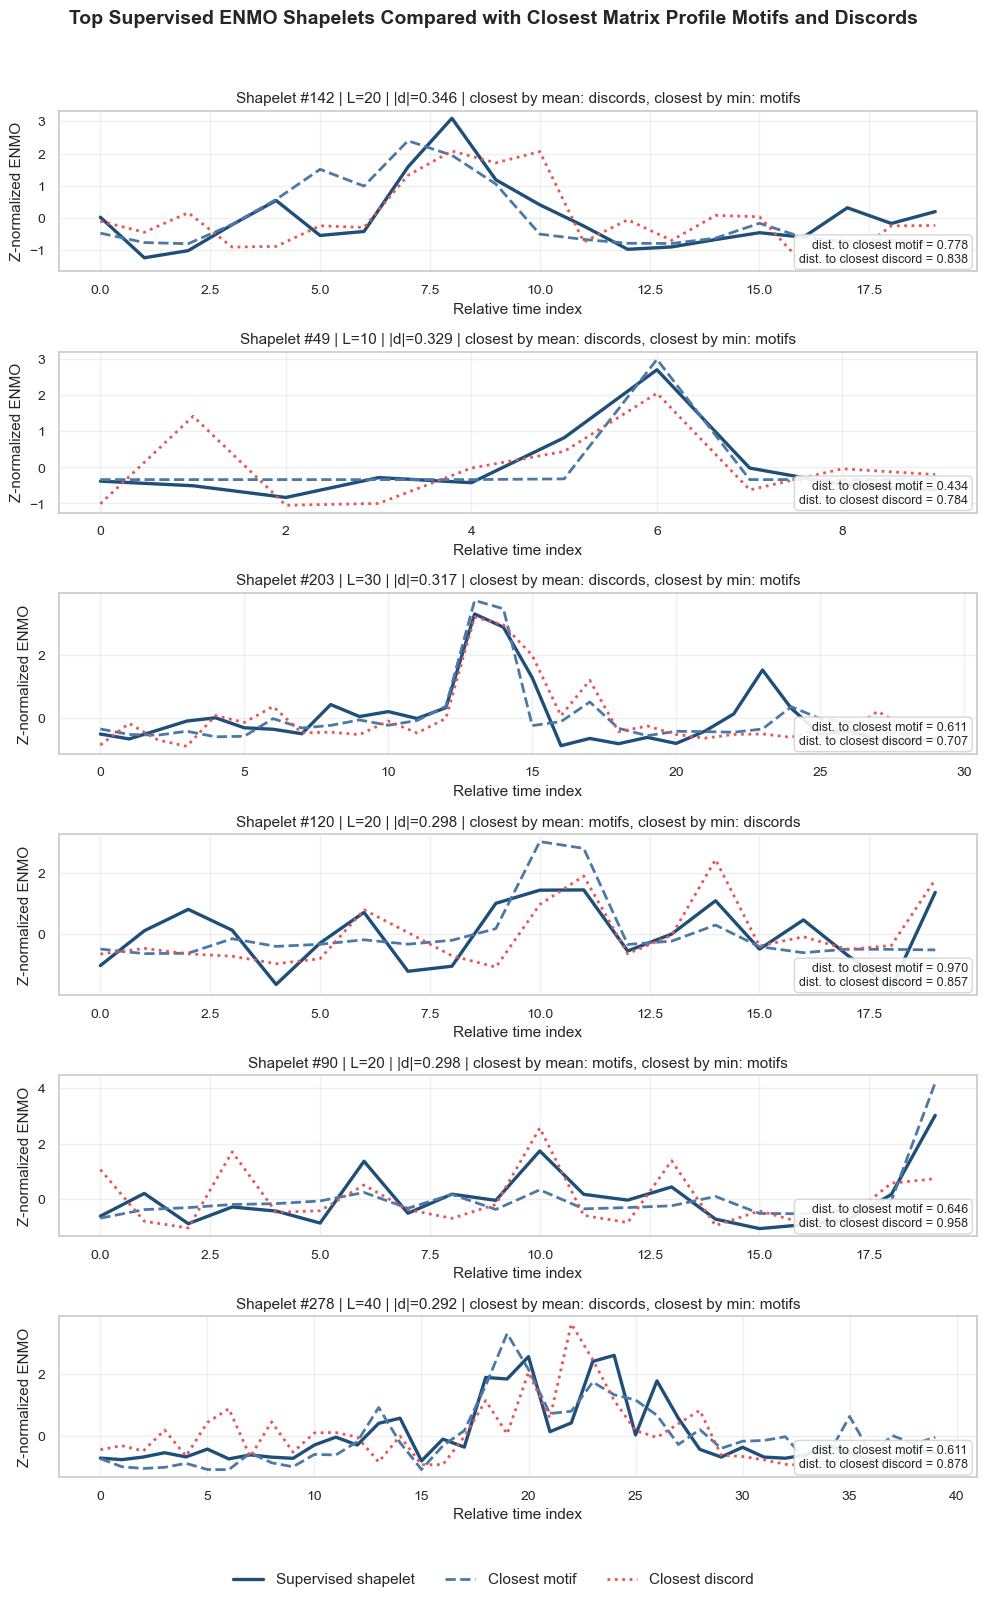

,candidate_id,length,shapelet_abs_cohen_d,closest_motif_distance,closest_discord_distance,closer_by_mean,closer_by_min
0,142,20,0.346080,0.778194,0.838401,discords,motifs
1,49,10,0.329265,0.434068,0.784189,discords,motifs
2,203,30,0.316689,0.610951,0.706852,discords,motifs
3,120,20,0.298457,0.969736,0.857349,motifs,discords
4,90,20,0.297644,0.645761,0.957923,motifs,motifs
5,278,40,0.292166,0.610809,0.878134,discords,motifs


Saved figure to: outputs/motifs_discords/top_shapelets_vs_motifs_discords.png


In [26]:
# ============================================================
# Cell 20 - Visualize top shapelets vs closest motifs/discords
# ============================================================

TOP_SHAPELETS_TO_PLOT = 6

shapelet_color = "#1f4e79"
motif_color = "#4C78A8"
discord_color = "#E45756"

top_shapelets_plot_df = top_shapelets_df.head(TOP_SHAPELETS_TO_PLOT).copy()

fig, axes = plt.subplots(
    nrows=TOP_SHAPELETS_TO_PLOT,
    ncols=1,
    figsize=(10, 2.6 * TOP_SHAPELETS_TO_PLOT),
    sharex=False
)

if TOP_SHAPELETS_TO_PLOT == 1:
    axes = [axes]

plot_rows = []

for ax, (_, shp) in zip(axes, top_shapelets_plot_df.iterrows()):

    candidate_id = int(shp["candidate_id"])
    L = int(shp["length"])
    shapelet_values = z_normalize_array(np.asarray(shp["values"], dtype=float))

    motif_refs = reference_by_length[L]["motifs"]
    discord_refs = reference_by_length[L]["discords"]

    # --------------------------------------------------------
    # Distances to motif and discord reference sets
    # --------------------------------------------------------
    dist_to_motifs = (
        np.linalg.norm(motif_refs - shapelet_values, axis=1) / np.sqrt(L)
    )

    dist_to_discords = (
        np.linalg.norm(discord_refs - shapelet_values, axis=1) / np.sqrt(L)
    )

    closest_motif_idx = int(np.argmin(dist_to_motifs))
    closest_discord_idx = int(np.argmin(dist_to_discords))

    closest_motif = motif_refs[closest_motif_idx]
    closest_discord = discord_refs[closest_discord_idx]

    closest_motif_distance = float(dist_to_motifs[closest_motif_idx])
    closest_discord_distance = float(dist_to_discords[closest_discord_idx])

    relationship_row = shapelet_motif_discord_relationship_df.loc[
        shapelet_motif_discord_relationship_df["candidate_id"] == candidate_id
    ].iloc[0]

    closer_by_mean = relationship_row["closer_to_by_mean"]
    closer_by_min = relationship_row["closer_to_by_min"]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    ax.plot(
        shapelet_values,
        color=shapelet_color,
        linewidth=2.4,
        label="Supervised shapelet"
    )

    ax.plot(
        closest_motif,
        color=motif_color,
        linewidth=2.0,
        linestyle="--",
        label=f"Closest motif"
    )

    ax.plot(
        closest_discord,
        color=discord_color,
        linewidth=2.0,
        linestyle=":",
        label=f"Closest discord"
    )

    ax.set_title(
        f"Shapelet #{candidate_id} | L={L} | "
        f"|d|={shp['score_abs_cohen_d']:.3f} | "
        f"closest by mean: {closer_by_mean}, closest by min: {closer_by_min}",
        fontsize=11
    )

    ax.set_xlabel("Relative time index")
    ax.set_ylabel("Z-normalized ENMO")
    ax.grid(True, alpha=0.30)

    ax.text(
        0.99,
        0.04,
        f"dist. to closest motif = {closest_motif_distance:.3f}\n"
        f"dist. to closest discord = {closest_discord_distance:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.90
        )
    )

    plot_rows.append({
        "candidate_id": candidate_id,
        "length": L,
        "shapelet_abs_cohen_d": shp["score_abs_cohen_d"],
        "closest_motif_distance": closest_motif_distance,
        "closest_discord_distance": closest_discord_distance,
        "closer_by_mean": closer_by_mean,
        "closer_by_min": closer_by_min
    })

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)
)

fig.suptitle(
    "Top Supervised ENMO Shapelets Compared with Closest Matrix Profile Motifs and Discords",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])

# ------------------------------------------------------------
# Save figure and comparison table
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

shapelet_relationship_plot_path = OUTPUT_DIR / "top_shapelets_vs_motifs_discords.png"

plt.savefig(
    shapelet_relationship_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

shapelet_relationship_plot_df = pd.DataFrame(plot_rows)
display(shapelet_relationship_plot_df)

print(f"Saved figure to: {shapelet_relationship_plot_path}")

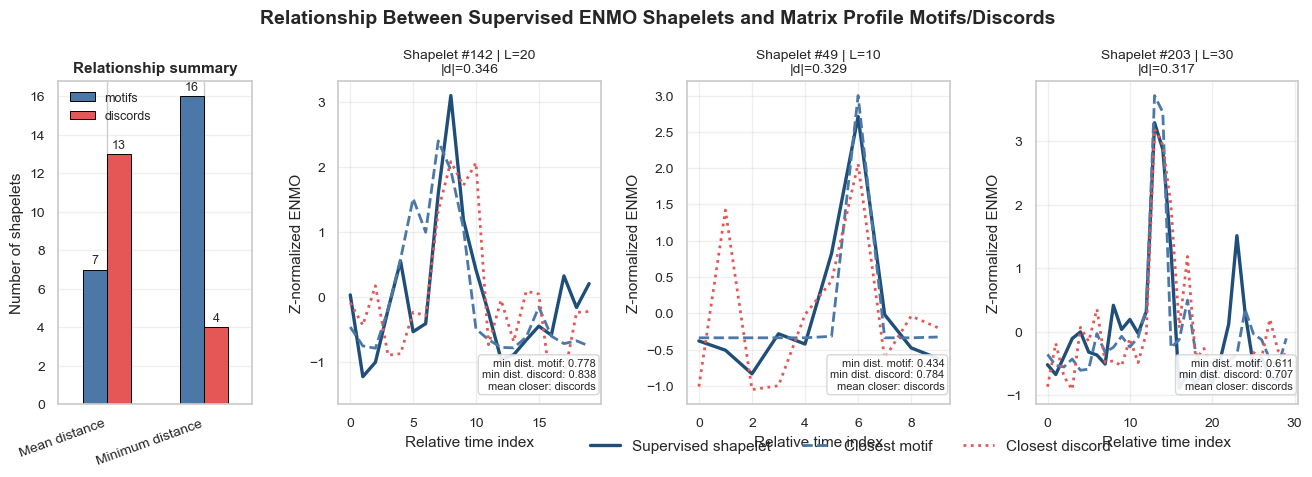

,candidate_id,length,shapelet_abs_cohen_d,closest_motif_distance,closest_discord_distance,closer_by_mean,closer_by_min
0,142,20,0.346080,0.778194,0.838401,discords,motifs
1,49,10,0.329265,0.434068,0.784189,discords,motifs
2,203,30,0.316689,0.610951,0.706852,discords,motifs


Saved compact figure to: outputs/motifs_discords/compact_shapelets_vs_motifs_discords.png


In [27]:
# ============================================================
# Cell 21 - Compact report-ready shapelet/motif/discord figure
# ============================================================

from matplotlib.lines import Line2D
from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
TOP_SHAPELETS_TO_PLOT = 3

shapelet_color = "#1f4e79"
motif_color = "#4C78A8"
discord_color = "#E45756"

top_shapelets_plot_df = top_shapelets_df.head(TOP_SHAPELETS_TO_PLOT).copy()

# ------------------------------------------------------------
# Prepare summary counts
# ------------------------------------------------------------
summary_mean = (
    shapelet_motif_discord_relationship_df["closer_to_by_mean"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

summary_min = (
    shapelet_motif_discord_relationship_df["closer_to_by_min"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

summary_counts = pd.DataFrame({
    "Mean distance": summary_mean,
    "Minimum distance": summary_min
}).T

# ------------------------------------------------------------
# Create compact figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 4.2))

gs = fig.add_gridspec(
    nrows=1,
    ncols=4,
    width_ratios=[0.85, 1.15, 1.15, 1.15],
    wspace=0.35
)

# ============================================================
# Panel A: summary barplot
# ============================================================
ax_summary = fig.add_subplot(gs[0, 0])

summary_counts.plot(
    kind="bar",
    ax=ax_summary,
    color=[motif_color, discord_color],
    edgecolor="black",
    linewidth=0.7
)

ax_summary.set_title("Relationship summary", fontsize=11, fontweight="bold")
ax_summary.set_ylabel("Number of shapelets")
ax_summary.set_xlabel("")
ax_summary.set_xticklabels(summary_counts.index, rotation=20, ha="right")
ax_summary.grid(axis="y", alpha=0.30)
ax_summary.legend(title="", frameon=False, fontsize=9)

# Add count labels
for container in ax_summary.containers:
    ax_summary.bar_label(container, fontsize=9, padding=2)

# ============================================================
# Panels B-D: top shapelets
# ============================================================
axes_shapelets = [
    fig.add_subplot(gs[0, i])
    for i in range(1, 4)
]

plot_rows = []

for ax, (_, shp) in zip(axes_shapelets, top_shapelets_plot_df.iterrows()):

    candidate_id = int(shp["candidate_id"])
    L = int(shp["length"])
    shapelet_values = z_normalize_array(np.asarray(shp["values"], dtype=float))

    motif_refs = reference_by_length[L]["motifs"]
    discord_refs = reference_by_length[L]["discords"]

    dist_to_motifs = (
        np.linalg.norm(motif_refs - shapelet_values, axis=1) / np.sqrt(L)
    )

    dist_to_discords = (
        np.linalg.norm(discord_refs - shapelet_values, axis=1) / np.sqrt(L)
    )

    closest_motif_idx = int(np.argmin(dist_to_motifs))
    closest_discord_idx = int(np.argmin(dist_to_discords))

    closest_motif = motif_refs[closest_motif_idx]
    closest_discord = discord_refs[closest_discord_idx]

    closest_motif_distance = float(dist_to_motifs[closest_motif_idx])
    closest_discord_distance = float(dist_to_discords[closest_discord_idx])

    relationship_row = shapelet_motif_discord_relationship_df.loc[
        shapelet_motif_discord_relationship_df["candidate_id"] == candidate_id
    ].iloc[0]

    closer_by_mean = relationship_row["closer_to_by_mean"]
    closer_by_min = relationship_row["closer_to_by_min"]

    # --------------------------------------------------------
    # Plot shapelet and closest references
    # --------------------------------------------------------
    ax.plot(
        shapelet_values,
        color=shapelet_color,
        linewidth=2.4,
        label="Shapelet"
    )

    ax.plot(
        closest_motif,
        color=motif_color,
        linewidth=2.0,
        linestyle="--",
        label="Closest motif"
    )

    ax.plot(
        closest_discord,
        color=discord_color,
        linewidth=2.0,
        linestyle=":",
        label="Closest discord"
    )

    ax.set_title(
        f"Shapelet #{candidate_id} | L={L}\n"
        f"|d|={shp['score_abs_cohen_d']:.3f}",
        fontsize=10
    )

    ax.set_xlabel("Relative time index")
    ax.set_ylabel("Z-normalized ENMO")
    ax.grid(True, alpha=0.30)

    ax.text(
        0.98,
        0.04,
        f"min dist. motif: {closest_motif_distance:.3f}\n"
        f"min dist. discord: {closest_discord_distance:.3f}\n"
        f"mean closer: {closer_by_mean}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.30",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.90
        )
    )

    plot_rows.append({
        "candidate_id": candidate_id,
        "length": L,
        "shapelet_abs_cohen_d": float(shp["score_abs_cohen_d"]),
        "closest_motif_distance": closest_motif_distance,
        "closest_discord_distance": closest_discord_distance,
        "closer_by_mean": closer_by_mean,
        "closer_by_min": closer_by_min
    })

# ------------------------------------------------------------
# Shared legend and title
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=shapelet_color, linewidth=2.4, label="Supervised shapelet"),
    Line2D([0], [0], color=motif_color, linewidth=2.0, linestyle="--", label="Closest motif"),
    Line2D([0], [0], color=discord_color, linewidth=2.0, linestyle=":", label="Closest discord"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.62, -0.04)
)

fig.suptitle(
    "Relationship Between Supervised ENMO Shapelets and Matrix Profile Motifs/Discords",
    fontsize=14,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

compact_shapelet_relationship_path = (
    OUTPUT_DIR / "compact_shapelets_vs_motifs_discords.png"
)

plt.savefig(
    compact_shapelet_relationship_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

compact_shapelet_relationship_df = pd.DataFrame(plot_rows)
display(compact_shapelet_relationship_df)

print(f"Saved compact figure to: {compact_shapelet_relationship_path}")

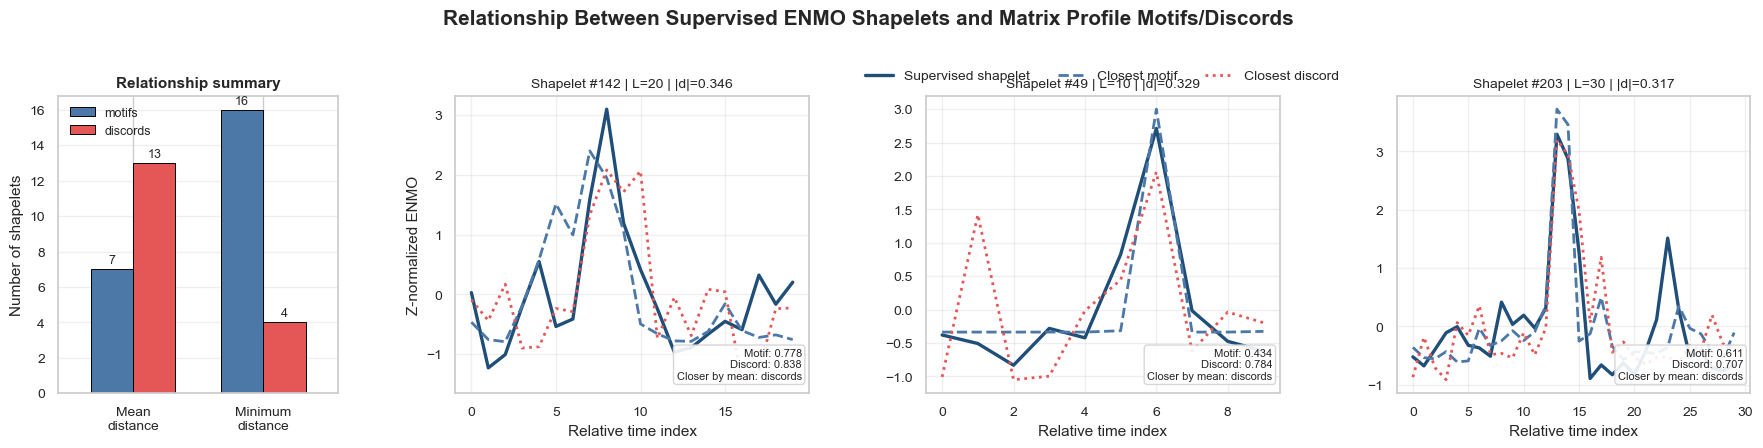

,candidate_id,length,shapelet_abs_cohen_d,closest_motif_distance,closest_discord_distance,closer_by_mean,closer_by_min
0,142,20,0.346080,0.778194,0.838401,discords,motifs
1,49,10,0.329265,0.434068,0.784189,discords,motifs
2,203,30,0.316689,0.610951,0.706852,discords,motifs


Saved compact figure to: outputs/motifs_discords/compact_shapelets_vs_motifs_discords_fixed.png


In [28]:
# ============================================================
# Cell 21 - Fixed compact report-ready shapelet/motif/discord figure
# ============================================================

from matplotlib.lines import Line2D
from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
TOP_SHAPELETS_TO_PLOT = 3

shapelet_color = "#1f4e79"
motif_color = "#4C78A8"
discord_color = "#E45756"

top_shapelets_plot_df = top_shapelets_df.head(TOP_SHAPELETS_TO_PLOT).copy()

# ------------------------------------------------------------
# Prepare summary counts
# ------------------------------------------------------------
summary_mean = (
    shapelet_motif_discord_relationship_df["closer_to_by_mean"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

summary_min = (
    shapelet_motif_discord_relationship_df["closer_to_by_min"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

summary_counts = pd.DataFrame({
    "Mean distance": summary_mean,
    "Minimum distance": summary_min
}).T

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(18, 4.8))

gs = fig.add_gridspec(
    nrows=1,
    ncols=4,
    width_ratios=[0.95, 1.2, 1.2, 1.2],
    wspace=0.35
)

# ============================================================
# Panel A: summary barplot
# ============================================================
ax_summary = fig.add_subplot(gs[0, 0])

summary_counts.plot(
    kind="bar",
    ax=ax_summary,
    color=[motif_color, discord_color],
    edgecolor="black",
    linewidth=0.7,
    width=0.65
)

ax_summary.set_title("Relationship summary", fontsize=11, fontweight="bold")
ax_summary.set_ylabel("Number of shapelets")
ax_summary.set_xlabel("")
ax_summary.set_xticklabels(["Mean\ndistance", "Minimum\ndistance"], rotation=0)
ax_summary.grid(axis="y", alpha=0.30)
ax_summary.legend(title="", frameon=False, fontsize=9, loc="upper left")

for container in ax_summary.containers:
    ax_summary.bar_label(container, fontsize=9, padding=2)

# ============================================================
# Panels B-D: top shapelets
# ============================================================
axes_shapelets = [
    fig.add_subplot(gs[0, i])
    for i in range(1, 4)
]

plot_rows = []

for j, (ax, (_, shp)) in enumerate(zip(axes_shapelets, top_shapelets_plot_df.iterrows())):

    candidate_id = int(shp["candidate_id"])
    L = int(shp["length"])
    shapelet_values = z_normalize_array(np.asarray(shp["values"], dtype=float))

    motif_refs = reference_by_length[L]["motifs"]
    discord_refs = reference_by_length[L]["discords"]

    dist_to_motifs = (
        np.linalg.norm(motif_refs - shapelet_values, axis=1) / np.sqrt(L)
    )

    dist_to_discords = (
        np.linalg.norm(discord_refs - shapelet_values, axis=1) / np.sqrt(L)
    )

    closest_motif_idx = int(np.argmin(dist_to_motifs))
    closest_discord_idx = int(np.argmin(dist_to_discords))

    closest_motif = motif_refs[closest_motif_idx]
    closest_discord = discord_refs[closest_discord_idx]

    closest_motif_distance = float(dist_to_motifs[closest_motif_idx])
    closest_discord_distance = float(dist_to_discords[closest_discord_idx])

    relationship_row = shapelet_motif_discord_relationship_df.loc[
        shapelet_motif_discord_relationship_df["candidate_id"] == candidate_id
    ].iloc[0]

    closer_by_mean = relationship_row["closer_to_by_mean"]
    closer_by_min = relationship_row["closer_to_by_min"]

    # Plot
    ax.plot(
        shapelet_values,
        color=shapelet_color,
        linewidth=2.4,
        label="Shapelet"
    )

    ax.plot(
        closest_motif,
        color=motif_color,
        linewidth=2.0,
        linestyle="--",
        label="Closest motif"
    )

    ax.plot(
        closest_discord,
        color=discord_color,
        linewidth=2.0,
        linestyle=":",
        label="Closest discord"
    )

    ax.set_title(
        f"Shapelet #{candidate_id} | L={L} | |d|={shp['score_abs_cohen_d']:.3f}",
        fontsize=10
    )

    ax.set_xlabel("Relative time index")

    if j == 0:
        ax.set_ylabel("Z-normalized ENMO")
    else:
        ax.set_ylabel("")

    ax.grid(True, alpha=0.30)

    ax.text(
        0.98,
        0.04,
        f"Motif: {closest_motif_distance:.3f}\n"
        f"Discord: {closest_discord_distance:.3f}\n"
        f"Closer by mean: {closer_by_mean}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.90
        )
    )

    plot_rows.append({
        "candidate_id": candidate_id,
        "length": L,
        "shapelet_abs_cohen_d": float(shp["score_abs_cohen_d"]),
        "closest_motif_distance": closest_motif_distance,
        "closest_discord_distance": closest_discord_distance,
        "closer_by_mean": closer_by_mean,
        "closer_by_min": closer_by_min
    })

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=shapelet_color, linewidth=2.4, label="Supervised shapelet"),
    Line2D([0], [0], color=motif_color, linewidth=2.0, linestyle="--", label="Closest motif"),
    Line2D([0], [0], color=discord_color, linewidth=2.0, linestyle=":", label="Closest discord"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.63, 0.88),
    fontsize=10
)

# ------------------------------------------------------------
# Global title and spacing
# ------------------------------------------------------------
fig.suptitle(
    "Relationship Between Supervised ENMO Shapelets and Matrix Profile Motifs/Discords",
    fontsize=15,
    fontweight="bold",
    y=0.98
)

fig.subplots_adjust(
    left=0.05,
    right=0.99,
    top=0.80,
    bottom=0.18,
    wspace=0.35
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

compact_shapelet_relationship_path = (
    OUTPUT_DIR / "compact_shapelets_vs_motifs_discords_fixed.png"
)

plt.savefig(
    compact_shapelet_relationship_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

compact_shapelet_relationship_df = pd.DataFrame(plot_rows)
display(compact_shapelet_relationship_df)

print(f"Saved compact figure to: {compact_shapelet_relationship_path}")

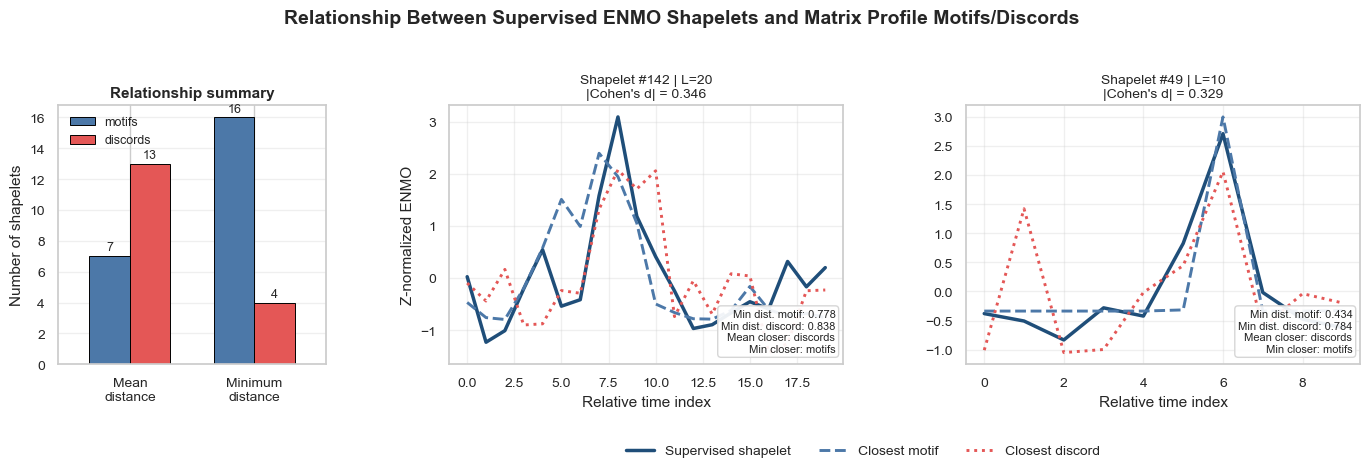

,candidate_id,length,shapelet_abs_cohen_d,closest_motif_distance,closest_discord_distance,closer_by_mean,closer_by_min
0,142,20,0.346080,0.778194,0.838401,discords,motifs
1,49,10,0.329265,0.434068,0.784189,discords,motifs


Saved compact figure to: outputs/motifs_discords/compact_shapelets_vs_motifs_discords_top2.png


In [29]:
# ============================================================
# Cell 21 - Compact report-ready figure with top 2 shapelets
# ============================================================

from matplotlib.lines import Line2D
from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
TOP_SHAPELETS_TO_PLOT = 2

shapelet_color = "#1f4e79"
motif_color = "#4C78A8"
discord_color = "#E45756"

top_shapelets_plot_df = top_shapelets_df.head(TOP_SHAPELETS_TO_PLOT).copy()

# ------------------------------------------------------------
# Prepare summary counts
# ------------------------------------------------------------
summary_mean = (
    shapelet_motif_discord_relationship_df["closer_to_by_mean"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

summary_min = (
    shapelet_motif_discord_relationship_df["closer_to_by_min"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

summary_counts = pd.DataFrame({
    "Mean distance": summary_mean,
    "Minimum distance": summary_min
}).T

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 4.8))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[0.85, 1.25, 1.25],
    wspace=0.35
)

# ============================================================
# Panel A: relationship summary
# ============================================================
ax_summary = fig.add_subplot(gs[0, 0])

summary_counts.plot(
    kind="bar",
    ax=ax_summary,
    color=[motif_color, discord_color],
    edgecolor="black",
    linewidth=0.7,
    width=0.65
)

ax_summary.set_title("Relationship summary", fontsize=11, fontweight="bold")
ax_summary.set_ylabel("Number of shapelets")
ax_summary.set_xlabel("")
ax_summary.set_xticklabels(["Mean\ndistance", "Minimum\ndistance"], rotation=0)
ax_summary.grid(axis="y", alpha=0.30)
ax_summary.legend(title="", frameon=False, fontsize=9, loc="upper left")

for container in ax_summary.containers:
    ax_summary.bar_label(container, fontsize=9, padding=2)

# ============================================================
# Panels B-C: top two shapelets
# ============================================================
axes_shapelets = [
    fig.add_subplot(gs[0, i])
    for i in range(1, 3)
]

plot_rows = []

for j, (ax, (_, shp)) in enumerate(zip(axes_shapelets, top_shapelets_plot_df.iterrows())):

    candidate_id = int(shp["candidate_id"])
    L = int(shp["length"])
    shapelet_values = z_normalize_array(np.asarray(shp["values"], dtype=float))

    motif_refs = reference_by_length[L]["motifs"]
    discord_refs = reference_by_length[L]["discords"]

    dist_to_motifs = (
        np.linalg.norm(motif_refs - shapelet_values, axis=1) / np.sqrt(L)
    )

    dist_to_discords = (
        np.linalg.norm(discord_refs - shapelet_values, axis=1) / np.sqrt(L)
    )

    closest_motif_idx = int(np.argmin(dist_to_motifs))
    closest_discord_idx = int(np.argmin(dist_to_discords))

    closest_motif = motif_refs[closest_motif_idx]
    closest_discord = discord_refs[closest_discord_idx]

    closest_motif_distance = float(dist_to_motifs[closest_motif_idx])
    closest_discord_distance = float(dist_to_discords[closest_discord_idx])

    relationship_row = shapelet_motif_discord_relationship_df.loc[
        shapelet_motif_discord_relationship_df["candidate_id"] == candidate_id
    ].iloc[0]

    closer_by_mean = relationship_row["closer_to_by_mean"]
    closer_by_min = relationship_row["closer_to_by_min"]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    ax.plot(
        shapelet_values,
        color=shapelet_color,
        linewidth=2.5,
        label="Supervised shapelet"
    )

    ax.plot(
        closest_motif,
        color=motif_color,
        linewidth=2.1,
        linestyle="--",
        label="Closest motif"
    )

    ax.plot(
        closest_discord,
        color=discord_color,
        linewidth=2.1,
        linestyle=":",
        label="Closest discord"
    )

    ax.set_title(
        f"Shapelet #{candidate_id} | L={L}\n"
        f"|Cohen's d| = {shp['score_abs_cohen_d']:.3f}",
        fontsize=10
    )

    ax.set_xlabel("Relative time index")

    if j == 0:
        ax.set_ylabel("Z-normalized ENMO")
    else:
        ax.set_ylabel("")

    ax.grid(True, alpha=0.30)

    ax.text(
        0.98,
        0.04,
        f"Min dist. motif: {closest_motif_distance:.3f}\n"
        f"Min dist. discord: {closest_discord_distance:.3f}\n"
        f"Mean closer: {closer_by_mean}\n"
        f"Min closer: {closer_by_min}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.30",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.92
        )
    )

    plot_rows.append({
        "candidate_id": candidate_id,
        "length": L,
        "shapelet_abs_cohen_d": float(shp["score_abs_cohen_d"]),
        "closest_motif_distance": closest_motif_distance,
        "closest_discord_distance": closest_discord_distance,
        "closer_by_mean": closer_by_mean,
        "closer_by_min": closer_by_min
    })

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=shapelet_color, linewidth=2.5, label="Supervised shapelet"),
    Line2D([0], [0], color=motif_color, linewidth=2.1, linestyle="--", label="Closest motif"),
    Line2D([0], [0], color=discord_color, linewidth=2.1, linestyle=":", label="Closest discord"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.63, 0.02),
    fontsize=10
)

# ------------------------------------------------------------
# Global title and spacing
# ------------------------------------------------------------
fig.suptitle(
    "Relationship Between Supervised ENMO Shapelets and Matrix Profile Motifs/Discords",
    fontsize=14,
    fontweight="bold",
    y=0.98
)

fig.subplots_adjust(
    left=0.055,
    right=0.985,
    top=0.78,
    bottom=0.24,
    wspace=0.35
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

compact_shapelet_relationship_path = (
    OUTPUT_DIR / "compact_shapelets_vs_motifs_discords_top2.png"
)

plt.savefig(
    compact_shapelet_relationship_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

compact_shapelet_relationship_df = pd.DataFrame(plot_rows)
display(compact_shapelet_relationship_df)

print(f"Saved compact figure to: {compact_shapelet_relationship_path}")

## Using DTW and Sakoe-Chiba

In [30]:
# ============================================================
# Shapelet--motif/discord relationship using DTW distance
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
TOP_SHAPELETS_TO_COMPARE = 20

# Sakoe-Chiba constraint.
# Example: 0.20 means the warping path can deviate by 20% of the sequence length.
# Set to None for unconstrained DTW.
DTW_WINDOW_FRACTION = 0.20

OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
required_objects = [
    "top_shapelets_df",
    "reference_by_length",
    "shapelet_motif_discord_relationship_df"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. Run the previous shapelet/motif/discord "
            "Euclidean relationship cells first."
        )


# ------------------------------------------------------------
# Utility: z-normalization
# ------------------------------------------------------------
def z_normalize_1d(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / max(np.std(x), eps)


# ------------------------------------------------------------
# Utility: constrained DTW distance
# ------------------------------------------------------------
def dtw_distance(x, y, window=None, normalize=True):
    """
    Compute DTW distance between two one-dimensional sequences.

    Parameters
    ----------
    x, y : array-like
        Input sequences.
    window : int or None
        Sakoe-Chiba radius. If None, unconstrained DTW is used.
    normalize : bool
        If True, divide final distance by sqrt(path-normalizing length proxy).

    Returns
    -------
    float
        DTW distance.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n = len(x)
    m = len(y)

    if window is None:
        window = max(n, m)
    else:
        window = max(int(window), abs(n - m))

    # Dynamic programming matrix
    dtw = np.full((n + 1, m + 1), np.inf, dtype=float)
    dtw[0, 0] = 0.0

    for i in range(1, n + 1):
        j_start = max(1, i - window)
        j_end = min(m, i + window) + 1

        for j in range(j_start, j_end):
            cost = (x[i - 1] - y[j - 1]) ** 2

            dtw[i, j] = cost + min(
                dtw[i - 1, j],      # insertion
                dtw[i, j - 1],      # deletion
                dtw[i - 1, j - 1]   # match
            )

    dist = np.sqrt(dtw[n, m])

    if normalize:
        # Keeps distances roughly comparable across lengths.
        dist = dist / np.sqrt(max(n, m))

    return float(dist)


def compute_dtw_distances_to_references(shapelet_values, reference_matrix, window_fraction=0.20):
    """
    Compute DTW distances between one shapelet and all motif/discord references.
    """

    shapelet_values = z_normalize_1d(shapelet_values)
    L = len(shapelet_values)

    if window_fraction is None:
        window = None
    else:
        window = max(1, int(np.ceil(window_fraction * L)))

    distances = np.empty(reference_matrix.shape[0], dtype=float)

    for i in range(reference_matrix.shape[0]):
        ref = z_normalize_1d(reference_matrix[i])

        distances[i] = dtw_distance(
            shapelet_values,
            ref,
            window=window,
            normalize=True
        )

    return distances


# ------------------------------------------------------------
# DTW comparison between top shapelets and motif/discord references
# ------------------------------------------------------------
dtw_relationship_rows = []

top_shapelets_for_dtw = top_shapelets_df.head(TOP_SHAPELETS_TO_COMPARE).copy()

for rank, (_, shp) in enumerate(
    tqdm(
        top_shapelets_for_dtw.iterrows(),
        total=len(top_shapelets_for_dtw),
        desc="Computing DTW shapelet relationships"
    ),
    start=1
):

    L = int(shp["length"])
    candidate_id = int(shp["candidate_id"])

    shapelet_values = z_normalize_1d(np.asarray(shp["values"], dtype=float))

    motif_refs = reference_by_length[L]["motifs"]
    discord_refs = reference_by_length[L]["discords"]

    motif_targets = reference_by_length[L]["motif_targets"]
    discord_targets = reference_by_length[L]["discord_targets"]

    # --------------------------------------------------------
    # DTW distances
    # --------------------------------------------------------
    dist_to_motifs_dtw = compute_dtw_distances_to_references(
        shapelet_values=shapelet_values,
        reference_matrix=motif_refs,
        window_fraction=DTW_WINDOW_FRACTION
    )

    dist_to_discords_dtw = compute_dtw_distances_to_references(
        shapelet_values=shapelet_values,
        reference_matrix=discord_refs,
        window_fraction=DTW_WINDOW_FRACTION
    )

    # --------------------------------------------------------
    # Aggregate distances
    # --------------------------------------------------------
    mean_motif_distance = float(np.mean(dist_to_motifs_dtw))
    mean_discord_distance = float(np.mean(dist_to_discords_dtw))

    median_motif_distance = float(np.median(dist_to_motifs_dtw))
    median_discord_distance = float(np.median(dist_to_discords_dtw))

    min_motif_distance = float(np.min(dist_to_motifs_dtw))
    min_discord_distance = float(np.min(dist_to_discords_dtw))

    closer_to_by_mean = (
        "motifs" if mean_motif_distance < mean_discord_distance else "discords"
    )

    closer_to_by_median = (
        "motifs" if median_motif_distance < median_discord_distance else "discords"
    )

    closer_to_by_min = (
        "motifs" if min_motif_distance < min_discord_distance else "discords"
    )

    # --------------------------------------------------------
    # Class-specific DTW distances
    # --------------------------------------------------------
    dist_to_motifs_0 = dist_to_motifs_dtw[motif_targets == 0]
    dist_to_motifs_1 = dist_to_motifs_dtw[motif_targets == 1]

    dist_to_discords_0 = dist_to_discords_dtw[discord_targets == 0]
    dist_to_discords_1 = dist_to_discords_dtw[discord_targets == 1]

    dtw_relationship_rows.append({
        "rank": rank,
        "candidate_id": candidate_id,
        "length": L,
        "source_target": int(shp["source_target"]),
        "source_subject_id": shp["source_subject_id"],
        "source_series_index": int(shp["source_series_index"]),
        "source_start": int(shp["start"]),

        "shapelet_abs_cohen_d": float(shp["score_abs_cohen_d"]),
        "shapelet_cohen_d_1_vs_0": float(shp["cohen_d_1_vs_0"]),

        "dtw_window_fraction": DTW_WINDOW_FRACTION,
        "dtw_window_radius": None if DTW_WINDOW_FRACTION is None else int(np.ceil(DTW_WINDOW_FRACTION * L)),

        "mean_dtw_to_motifs": mean_motif_distance,
        "mean_dtw_to_discords": mean_discord_distance,
        "median_dtw_to_motifs": median_motif_distance,
        "median_dtw_to_discords": median_discord_distance,
        "min_dtw_to_motifs": min_motif_distance,
        "min_dtw_to_discords": min_discord_distance,

        "mean_discord_minus_motif_dtw": mean_discord_distance - mean_motif_distance,
        "median_discord_minus_motif_dtw": median_discord_distance - median_motif_distance,
        "min_discord_minus_motif_dtw": min_discord_distance - min_motif_distance,

        "closer_to_by_mean_dtw": closer_to_by_mean,
        "closer_to_by_median_dtw": closer_to_by_median,
        "closer_to_by_min_dtw": closer_to_by_min,

        "mean_dtw_to_motifs_target_0": float(np.mean(dist_to_motifs_0)),
        "mean_dtw_to_motifs_target_1": float(np.mean(dist_to_motifs_1)),
        "mean_dtw_to_discords_target_0": float(np.mean(dist_to_discords_0)),
        "mean_dtw_to_discords_target_1": float(np.mean(dist_to_discords_1)),
    })

shapelet_motif_discord_relationship_dtw_df = pd.DataFrame(dtw_relationship_rows)

# ------------------------------------------------------------
# Display compact results
# ------------------------------------------------------------
display_dtw_df = shapelet_motif_discord_relationship_dtw_df.copy()
numeric_cols = display_dtw_df.select_dtypes(include=[np.number]).columns
display_dtw_df[numeric_cols] = display_dtw_df[numeric_cols].round(4)

print("DTW relationship between top supervised shapelets and Matrix Profile motifs/discords:")
display(display_dtw_df)

print("\nSummary: closer to motifs or discords by DTW mean distance")
display(
    shapelet_motif_discord_relationship_dtw_df["closer_to_by_mean_dtw"]
    .value_counts()
)

print("\nSummary: closer to motifs or discords by DTW median distance")
display(
    shapelet_motif_discord_relationship_dtw_df["closer_to_by_median_dtw"]
    .value_counts()
)

print("\nSummary: closer to motifs or discords by DTW minimum distance")
display(
    shapelet_motif_discord_relationship_dtw_df["closer_to_by_min_dtw"]
    .value_counts()
)

# ------------------------------------------------------------
# Save DTW relationship table
# ------------------------------------------------------------
dtw_relationship_path = OUTPUT_DIR / "shapelet_motif_discord_relationship_dtw.csv"

shapelet_motif_discord_relationship_dtw_df.to_csv(
    dtw_relationship_path,
    index=False
)

print(f"\nSaved DTW relationship table to: {dtw_relationship_path}")

Computing DTW shapelet relationships: 100%|██████████| 20/20 [00:02<00:00,  9.44it/s]


DTW relationship between top supervised shapelets and Matrix Profile motifs/discords:


,rank,candidate_id,length,source_target,source_subject_id,source_series_index,source_start,shapelet_abs_cohen_d,shapelet_cohen_d_1_vs_0,dtw_window_fraction,...,mean_discord_minus_motif_dtw,median_discord_minus_motif_dtw,min_discord_minus_motif_dtw,closer_to_by_mean_dtw,closer_to_by_median_dtw,closer_to_by_min_dtw,mean_dtw_to_motifs_target_0,mean_dtw_to_motifs_target_1,mean_dtw_to_discords_target_0,mean_dtw_to_discords_target_1
0,1,142,20,1,1721,1262,46,0.3461,0.3461,0.2,...,-0.2519,-0.3264,0.1591,discords,discords,motifs,1.1044,1.1062,0.8577,0.8491
1,2,49,10,0,1935,2157,176,0.3293,-0.3293,0.2,...,-0.2124,-0.3632,0.4086,discords,discords,motifs,1.2683,1.2048,1.0149,1.0334
2,3,203,30,1,1267,613,120,0.3167,0.3167,0.2,...,-0.2523,-0.3157,0.0466,discords,discords,motifs,1.1189,1.1534,0.8871,0.8806
3,4,120,20,0,924,1306,126,0.2985,0.2985,0.2,...,-0.1663,-0.1226,-0.1494,discords,discords,discords,1.0342,1.0530,0.8895,0.8652
4,5,90,20,0,799,603,140,0.2976,0.2976,0.2,...,0.0406,0.0540,0.1162,motifs,motifs,motifs,0.9517,0.9821,1.0160,0.9989
5,6,278,40,0,1524,2933,66,0.2922,0.2922,0.2,...,-0.1479,-0.1987,0.0609,discords,discords,motifs,1.0902,1.0790,0.9185,0.9550
6,7,40,10,1,969,215,175,0.2912,0.2912,0.2,...,0.2573,0.0662,0.4353,motifs,motifs,motifs,0.9635,1.0168,1.2432,1.2517
7,8,311,40,0,1412,1575,35,0.2901,0.2901,0.2,...,-0.1532,-0.1317,-0.0301,discords,discords,discords,0.9955,0.9911,0.8200,0.8602
8,9,10,10,1,1205,145,105,0.2860,-0.2860,0.2,...,-0.3577,-0.3500,0.0821,discords,discords,motifs,1.3249,1.2992,0.9682,0.9406
9,10,281,40,1,1088,41,114,0.2857,-0.2857,0.2,...,-0.2596,-0.3439,0.1741,discords,discords,motifs,1.3350,1.2690,1.0338,1.0509



Summary: closer to motifs or discords by DTW mean distance


closer_to_by_mean_dtw
discords    16
motifs       4
Name: count, dtype: int64


Summary: closer to motifs or discords by DTW median distance


closer_to_by_median_dtw
discords    15
motifs       5
Name: count, dtype: int64


Summary: closer to motifs or discords by DTW minimum distance


closer_to_by_min_dtw
motifs      17
discords     3
Name: count, dtype: int64


Saved DTW relationship table to: outputs/motifs_discords/shapelet_motif_discord_relationship_dtw.csv


In [31]:
# ============================================================
# DTW relationship summary table
# ============================================================

# ------------------------------------------------------------
# Compact summary counts
# ------------------------------------------------------------
dtw_summary_mean = (
    shapelet_motif_discord_relationship_dtw_df["closer_to_by_mean_dtw"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

dtw_summary_median = (
    shapelet_motif_discord_relationship_dtw_df["closer_to_by_median_dtw"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

dtw_summary_min = (
    shapelet_motif_discord_relationship_dtw_df["closer_to_by_min_dtw"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

dtw_summary_counts = pd.DataFrame({
    "Mean DTW distance": dtw_summary_mean,
    "Median DTW distance": dtw_summary_median,
    "Minimum DTW distance": dtw_summary_min
}).T

print("DTW summary: number of shapelets closer to motifs or discords")
display(dtw_summary_counts)

# ------------------------------------------------------------
# Compact relationship table
# ------------------------------------------------------------
dtw_compact_relationship_df = (
    shapelet_motif_discord_relationship_dtw_df[
        [
            "rank",
            "candidate_id",
            "length",
            "shapelet_abs_cohen_d",
            "mean_dtw_to_motifs",
            "mean_dtw_to_discords",
            "median_dtw_to_motifs",
            "median_dtw_to_discords",
            "min_dtw_to_motifs",
            "min_dtw_to_discords",
            "closer_to_by_mean_dtw",
            "closer_to_by_median_dtw",
            "closer_to_by_min_dtw"
        ]
    ]
    .copy()
)

numeric_cols = dtw_compact_relationship_df.select_dtypes(include=[np.number]).columns
dtw_compact_relationship_df[numeric_cols] = dtw_compact_relationship_df[numeric_cols].round(4)

print("\nCompact DTW relationship table:")
display(dtw_compact_relationship_df)

# ------------------------------------------------------------
# Save compact table
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dtw_compact_path = OUTPUT_DIR / "compact_shapelet_motif_discord_relationship_dtw.csv"
dtw_compact_relationship_df.to_csv(dtw_compact_path, index=False)

print(f"Saved compact DTW relationship table to: {dtw_compact_path}")

DTW summary: number of shapelets closer to motifs or discords


,motifs,discords
Mean DTW distance,4,16
Median DTW distance,5,15
Minimum DTW distance,17,3



Compact DTW relationship table:


,rank,candidate_id,length,shapelet_abs_cohen_d,mean_dtw_to_motifs,mean_dtw_to_discords,median_dtw_to_motifs,median_dtw_to_discords,min_dtw_to_motifs,min_dtw_to_discords,closer_to_by_mean_dtw,closer_to_by_median_dtw,closer_to_by_min_dtw
0,1,142,20,0.3461,1.1053,0.8534,1.1726,0.8462,0.3956,0.5547,discords,discords,motifs
1,2,49,10,0.3293,1.2365,1.0242,1.3806,1.0174,0.2048,0.6134,discords,discords,motifs
2,3,203,30,0.3167,1.1362,0.8838,1.1951,0.8793,0.3906,0.4372,discords,discords,motifs
3,4,120,20,0.2985,1.0436,0.8773,1.0001,0.8774,0.6402,0.4909,discords,discords,discords
4,5,90,20,0.2976,0.9669,1.0074,0.9826,1.0367,0.4401,0.5563,motifs,motifs,motifs
5,6,278,40,0.2922,1.0846,0.9367,1.1225,0.9238,0.4153,0.4761,discords,discords,motifs
6,7,40,10,0.2912,0.9901,1.2475,1.1810,1.2472,0.2685,0.7039,motifs,motifs,motifs
7,8,311,40,0.2901,0.9933,0.8401,0.9722,0.8404,0.4560,0.4259,discords,discords,discords
8,9,10,10,0.2860,1.3121,0.9544,1.3119,0.9619,0.4024,0.4845,discords,discords,motifs
9,10,281,40,0.2857,1.3020,1.0423,1.3856,1.0418,0.3545,0.5286,discords,discords,motifs


Saved compact DTW relationship table to: outputs/motifs_discords/compact_shapelet_motif_discord_relationship_dtw.csv


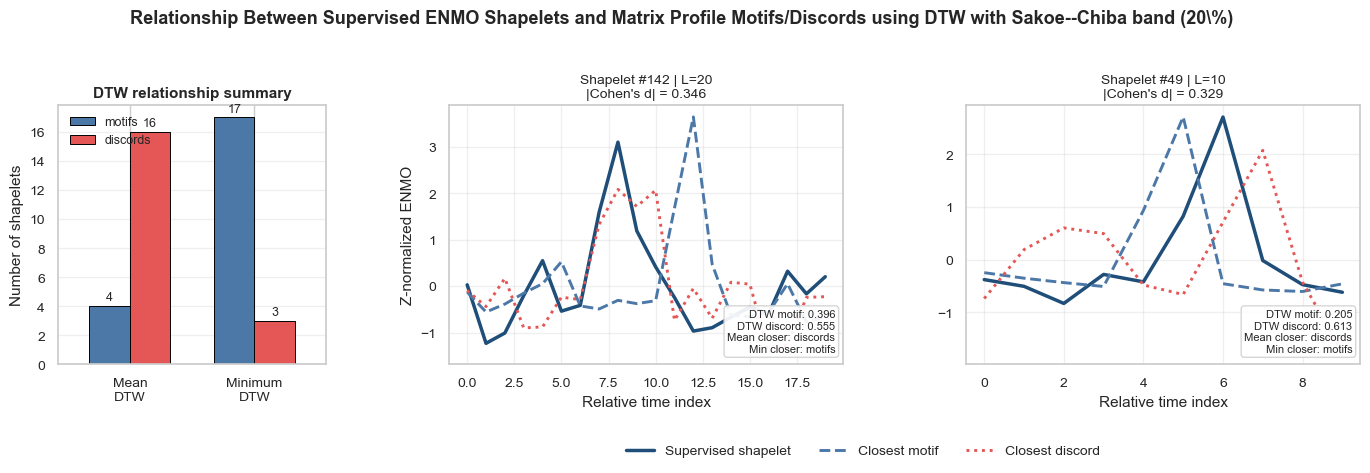

,candidate_id,length,shapelet_abs_cohen_d,closest_motif_dtw_distance,closest_discord_dtw_distance,closer_by_mean_dtw,closer_by_min_dtw
0,142,20,0.346080,0.395635,0.554687,discords,motifs
1,49,10,0.329265,0.204844,0.613434,discords,motifs


Saved compact DTW figure to: outputs/motifs_discords/compact_shapelets_vs_motifs_discords_dtw_top2.png
Saved compact DTW plot table to: outputs/motifs_discords/compact_shapelets_vs_motifs_discords_dtw_top2.csv


In [32]:
# ============================================================
# Compact report-ready DTW figure with top 2 shapelets
# ============================================================

from matplotlib.lines import Line2D
from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
TOP_SHAPELETS_TO_PLOT = 2

shapelet_color = "#1f4e79"
motif_color = "#4C78A8"
discord_color = "#E45756"

top_shapelets_plot_df = top_shapelets_df.head(TOP_SHAPELETS_TO_PLOT).copy()

# ------------------------------------------------------------
# Prepare DTW summary counts
# ------------------------------------------------------------
summary_mean_dtw = (
    shapelet_motif_discord_relationship_dtw_df["closer_to_by_mean_dtw"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

summary_min_dtw = (
    shapelet_motif_discord_relationship_dtw_df["closer_to_by_min_dtw"]
    .value_counts()
    .reindex(["motifs", "discords"], fill_value=0)
)

summary_counts_dtw = pd.DataFrame({
    "Mean DTW": summary_mean_dtw,
    "Minimum DTW": summary_min_dtw
}).T

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 4.8))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[0.85, 1.25, 1.25],
    wspace=0.35
)

# ============================================================
# Panel A: relationship summary
# ============================================================
ax_summary = fig.add_subplot(gs[0, 0])

summary_counts_dtw.plot(
    kind="bar",
    ax=ax_summary,
    color=[motif_color, discord_color],
    edgecolor="black",
    linewidth=0.7,
    width=0.65
)

ax_summary.set_title("DTW relationship summary", fontsize=11, fontweight="bold")
ax_summary.set_ylabel("Number of shapelets")
ax_summary.set_xlabel("")
ax_summary.set_xticklabels(["Mean\nDTW", "Minimum\nDTW"], rotation=0)
ax_summary.grid(axis="y", alpha=0.30)
ax_summary.legend(title="", frameon=False, fontsize=9, loc="upper left")

for container in ax_summary.containers:
    ax_summary.bar_label(container, fontsize=9, padding=2)

# ============================================================
# Panels B-C: top two shapelets
# ============================================================
axes_shapelets = [
    fig.add_subplot(gs[0, i])
    for i in range(1, 3)
]

plot_rows_dtw = []

for j, (ax, (_, shp)) in enumerate(zip(axes_shapelets, top_shapelets_plot_df.iterrows())):

    candidate_id = int(shp["candidate_id"])
    L = int(shp["length"])
    shapelet_values = z_normalize_1d(np.asarray(shp["values"], dtype=float))

    motif_refs = reference_by_length[L]["motifs"]
    discord_refs = reference_by_length[L]["discords"]

    # --------------------------------------------------------
    # DTW window
    # --------------------------------------------------------
    if DTW_WINDOW_FRACTION is None:
        dtw_window = None
    else:
        dtw_window = max(1, int(np.ceil(DTW_WINDOW_FRACTION * L)))

    # --------------------------------------------------------
    # DTW distances to motif references
    # --------------------------------------------------------
    dist_to_motifs_dtw = np.empty(motif_refs.shape[0], dtype=float)

    for i in range(motif_refs.shape[0]):
        dist_to_motifs_dtw[i] = dtw_distance(
            shapelet_values,
            z_normalize_1d(motif_refs[i]),
            window=dtw_window,
            normalize=True
        )

    # --------------------------------------------------------
    # DTW distances to discord references
    # --------------------------------------------------------
    dist_to_discords_dtw = np.empty(discord_refs.shape[0], dtype=float)

    for i in range(discord_refs.shape[0]):
        dist_to_discords_dtw[i] = dtw_distance(
            shapelet_values,
            z_normalize_1d(discord_refs[i]),
            window=dtw_window,
            normalize=True
        )

    closest_motif_idx = int(np.argmin(dist_to_motifs_dtw))
    closest_discord_idx = int(np.argmin(dist_to_discords_dtw))

    closest_motif = z_normalize_1d(motif_refs[closest_motif_idx])
    closest_discord = z_normalize_1d(discord_refs[closest_discord_idx])

    closest_motif_distance = float(dist_to_motifs_dtw[closest_motif_idx])
    closest_discord_distance = float(dist_to_discords_dtw[closest_discord_idx])

    relationship_row = shapelet_motif_discord_relationship_dtw_df.loc[
        shapelet_motif_discord_relationship_dtw_df["candidate_id"] == candidate_id
    ].iloc[0]

    closer_by_mean = relationship_row["closer_to_by_mean_dtw"]
    closer_by_min = relationship_row["closer_to_by_min_dtw"]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    ax.plot(
        shapelet_values,
        color=shapelet_color,
        linewidth=2.5,
        label="Supervised shapelet"
    )

    ax.plot(
        closest_motif,
        color=motif_color,
        linewidth=2.1,
        linestyle="--",
        label="Closest motif"
    )

    ax.plot(
        closest_discord,
        color=discord_color,
        linewidth=2.1,
        linestyle=":",
        label="Closest discord"
    )

    ax.set_title(
        f"Shapelet #{candidate_id} | L={L}\n"
        f"|Cohen's d| = {shp['score_abs_cohen_d']:.3f}",
        fontsize=10
    )

    ax.set_xlabel("Relative time index")

    if j == 0:
        ax.set_ylabel("Z-normalized ENMO")
    else:
        ax.set_ylabel("")

    ax.grid(True, alpha=0.30)

    ax.text(
        0.98,
        0.04,
        f"DTW motif: {closest_motif_distance:.3f}\n"
        f"DTW discord: {closest_discord_distance:.3f}\n"
        f"Mean closer: {closer_by_mean}\n"
        f"Min closer: {closer_by_min}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.30",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.92
        )
    )

    plot_rows_dtw.append({
        "candidate_id": candidate_id,
        "length": L,
        "shapelet_abs_cohen_d": float(shp["score_abs_cohen_d"]),
        "closest_motif_dtw_distance": closest_motif_distance,
        "closest_discord_dtw_distance": closest_discord_distance,
        "closer_by_mean_dtw": closer_by_mean,
        "closer_by_min_dtw": closer_by_min
    })

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=shapelet_color, linewidth=2.5, label="Supervised shapelet"),
    Line2D([0], [0], color=motif_color, linewidth=2.1, linestyle="--", label="Closest motif"),
    Line2D([0], [0], color=discord_color, linewidth=2.1, linestyle=":", label="Closest discord"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.63, 0.02),
    fontsize=10
)

# ------------------------------------------------------------
# Global title and spacing
# ------------------------------------------------------------
if DTW_WINDOW_FRACTION is None:
    dtw_title = "unconstrained DTW"
else:
    dtw_title = f"DTW with Sakoe--Chiba band ({int(DTW_WINDOW_FRACTION * 100)}\\%)"

fig.suptitle(
    f"Relationship Between Supervised ENMO Shapelets and Matrix Profile Motifs/Discords using {dtw_title}",
    fontsize=13,
    fontweight="bold",
    y=0.98
)

fig.subplots_adjust(
    left=0.055,
    right=0.985,
    top=0.78,
    bottom=0.24,
    wspace=0.35
)

# ------------------------------------------------------------
# Save figure and table
# ------------------------------------------------------------
OUTPUT_DIR = Path("outputs/motifs_discords")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

compact_shapelet_relationship_dtw_path = (
    OUTPUT_DIR / "compact_shapelets_vs_motifs_discords_dtw_top2.png"
)

plt.savefig(
    compact_shapelet_relationship_dtw_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

compact_shapelet_relationship_dtw_df = pd.DataFrame(plot_rows_dtw)
display(compact_shapelet_relationship_dtw_df)

dtw_plot_table_path = OUTPUT_DIR / "compact_shapelets_vs_motifs_discords_dtw_top2.csv"
compact_shapelet_relationship_dtw_df.to_csv(dtw_plot_table_path, index=False)

print(f"Saved compact DTW figure to: {compact_shapelet_relationship_dtw_path}")
print(f"Saved compact DTW plot table to: {dtw_plot_table_path}")